In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
import cvxpy as cp
from sklearn.covariance import LedoitWolf
from tqdm import tqdm
import geopandas as gpd
from shapely.geometry import box
from shapely import Point

In [2]:
Static = pd.read_excel("./Data_new/Static.xlsx")

# EScore = pd.read_excel("./Data/DS_EScore_Y.xlsx")
# SScore = pd.read_excel("./Data/DS_SScore_Y.xlsx")
GScore = pd.read_excel("./Data_new/DS_GScore_Y.xlsx")
# ESGScore = pd.read_excel("./Data/DS_ESGScore_Y.xlsx")

RI_m = pd.read_excel("./Data_new/DS_RI_USD_M.xlsx").iloc[:, :-1]
# RI_y = pd.read_excel("./Data/DS_RI_USD_Y.xlsx")
MC_m = pd.read_excel("./Data_new/DS_MV_USD_M.xlsx").iloc[:, :-1]
# MC_y = pd.read_excel("./Data/DS_MV_USD_Y.xlsx")
# REV_y = pd.read_excel("./Data_new/DS_REV_USD_Y.xlsx")

# Scope1 = pd.read_excel("./Data/Scope_1.xlsx")
# Scope2 = pd.read_excel("./Data/Scope_2.xlsx")


In [3]:
time = RI_m.iloc[:, 3:].columns # extract the timestamp index
RF_m = pd.read_excel("./Data_new/Risk_Free_Rate.xlsx", index_col=0)
RF_m = RF_m / 100
RF_m.index = time
RF_m = RF_m.T
RF_m.reset_index(drop=True, inplace=True)

# extract 2014-2024
RF_m_temp_original = RF_m.loc[:, (RF_m.columns >= pd.Timestamp("2014-01-01")) & (RF_m.columns <= pd.Timestamp("2024-12-31"))]
RF_m_temp = RF_m_temp_original.T

In [4]:
# Filter the firms:
# Condition 1: Europe
# Condition 2: GScore data avaiable
GScore_merged = GScore.merge(Static[['ISIN', 'Region']], on="ISIN")
GScore_eur = GScore_merged.loc[GScore_merged["Region"] == "EUR"].copy()
GScore_eur.reset_index(inplace=True, drop=True)
# GScore_eur.dropna(subset=[GScore_eur.columns[x] for x in range(16, 27)], inplace=True)


In [5]:
# Our dataset of group7
RI_m_eur = RI_m.merge(GScore_eur[["ISIN"]], on="ISIN", how="inner")
# RI_y_eur = RI_y.merge(GScore_eur[["ISIN"]], on="ISIN", how="inner")
MC_m_eur = MC_m.merge(GScore_eur[["ISIN"]], on="ISIN", how="inner")
# MC_y_eur = MC_y.merge(GScore_eur[["ISIN"]], on="ISIN", how="inner")
# REV_y_eur = REV_y.merge(GScore_eur[["ISIN"]], on="ISIN", how="inner")

# Data Cleaning


##### Clean RI_m_eur

In [6]:
# calculate the returns
temp = RI_m_eur.iloc[:, 2:].diff(axis=1) / RI_m_eur.iloc[:,2:].shift(axis=1)
# dropna if with continuously more than 12 NA
# mask = temp.isna().rolling(window=12, axis=1).agg(sum).max(axis=1) >= 12
# temp = temp[~mask]

# R_m = pd.concat([RI_m_eur[["NAME", "ISIN"]], temp], axis=1)

In [7]:
# Check if there are outliers in the data
((temp > 100) | (temp < -1)).sum().sum()

6

In [8]:
# replace the outliers with the average of the previous and next value
def replace_outliers(df):
    df_filled = df.copy()
    for index, row in df_filled.iterrows():
        outliers = (row < -100) | (row > 100)
        df_filled.loc[index, outliers] = (row.shift()[outliers] + row.shift(-1)[outliers]) / 2
    return df_filled

temp9924 = replace_outliers(temp)

In [9]:
((temp9924 > 100) | (temp9924 < -1)).sum().sum()

0

In [10]:
# fill NaN at the beginning/end with the average over the avaiable sample
def fill_na(df):
     df_filled = df.copy()
     for index, row in df_filled.iterrows():
          available_mean = row.dropna().mean()
          first_valid = row.index.get_loc(row.first_valid_index())
          last_valid = row.index.get_loc(row.last_valid_index()) # find the NaN at the beginning/end
          if first_valid != 0:
               df_filled.iloc[index, :first_valid] = available_mean
          if last_valid != len(row) - 1:
               df_filled.iloc[index, last_valid + 1:] = available_mean
     return df_filled

temp9924 = fill_na(temp9924)

In [11]:
# Linear interpolation for the missing value at the middle
temp9924 = temp9924.interpolate(method="linear" ,axis=1)

In [12]:
# extract 2014-2024
temp1424 = temp9924.loc[:, (temp9924.columns >= pd.Timestamp("2014-01-01")) & (temp9924.columns <= pd.Timestamp("2024-12-31"))].copy()

# extract 2004-2024
temp0424 = temp9924.loc[:, (temp9924.columns >= pd.Timestamp("2004-01-01")) & (temp9924.columns <= pd.Timestamp("2024-12-31"))].copy()

###### modify the data cleaning according to the feedback of HW1

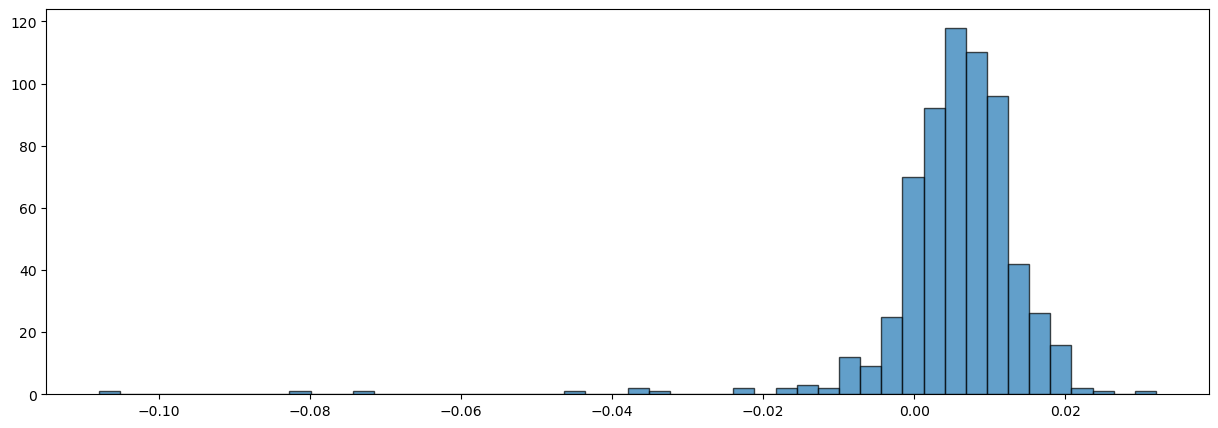

In [13]:
# find 3 extreme stocks using monthly average return over 2014-2024
avg_r = []
index_to_drop = []

for index, row in temp1424.iterrows():
    if row.mean() < -0.05:
        index_to_drop.append(index)
    avg_r.append(row.mean())

plt.figure(figsize = (15, 5))
plt.hist(avg_r, bins=50, edgecolor="black", alpha=0.7)
plt.show()

In [14]:
# drop the 3 extreme stocks
temp9924.drop(index_to_drop, inplace=True)
temp9924.reset_index(drop=True, inplace=True)

temp1424.drop(index_to_drop, inplace=True)
temp1424.reset_index(drop=True, inplace=True)

temp0424.drop(index_to_drop, inplace=True)
temp0424.reset_index(drop=True, inplace=True)

name_meta_633 = RI_m_eur.drop(index_to_drop)[["NAME", "ISIN"]].reset_index(drop=True)



In [15]:
# add country info to name_meta_633
name_meta_633 = name_meta_633.merge(Static[["ISIN", "Country"]], on="ISIN")
name_meta_633

,NAME,ISIN,Country
0,STRABAG SE,AT000000STR1,AT
1,FLUGHAFEN WIEN,AT00000VIE62,AT
2,RAIFFEISEN BANK INTL.,AT0000606306,AT
3,ERSTE GROUP BANK,AT0000652011,AT
4,TELEKOM AUSTRIA,AT0000720008,AT
...,...,...,...
628,BOLIDEN ORD SHS,SE0020050417,SE
629,AUTOLIV,US0528001094,SE
630,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,US70211M1099,IL
631,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,US8816242098,IL


In [16]:
# add the columns of company name and ISIN back to the cleaned table
R_m_filled = pd.concat([name_meta_633, temp9924], axis=1)

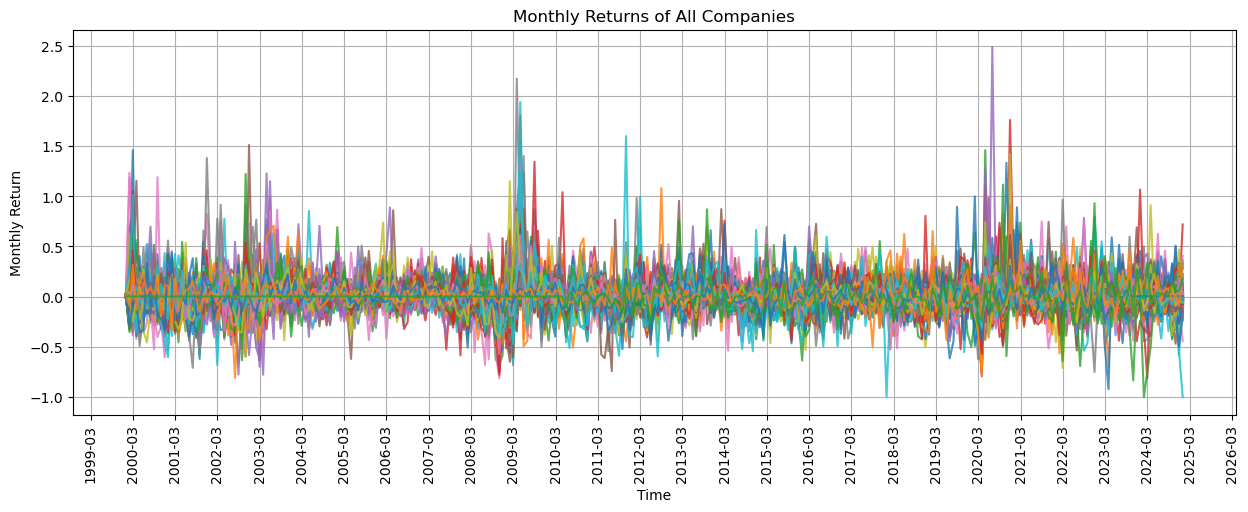

In [17]:
# Plot the monthly return of each company using cleaned dataset
fig, ax = plt.subplots(figsize=(15, 5))

for index, row in temp9924.iterrows():
    plt.plot(row, label=index, alpha=0.8)

plt.title("Monthly Returns of All Companies")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xlabel("Time")
plt.xticks(rotation=90)
plt.ylabel("Monthly Return")
plt.grid(True)
plt.show()


In [18]:
for index, row in R_m_filled.iterrows():
    if any(row.iloc[3: ] > 2.0):
        print(f"Company {row.iloc[1]} contains a monthly return over 2.0")

Company GB00B3DGH821 contains a monthly return over 2.0
Company IE00BD1RP616 contains a monthly return over 2.0


##### Clean MC_m_eur

In [19]:
temp_mc = MC_m_eur.iloc[:, 2:].copy()

temp_mc.drop(index_to_drop, inplace=True)
temp_mc.reset_index(drop=True, inplace=True)

temp_mc = fill_na(temp_mc)
temp9924_mc = temp_mc.astype(float).interpolate(method="linear", axis=1)

In [20]:
temp9924_mc.isna().sum().sum()

0

In [21]:
# extract 2014-2024
temp1424_mc = temp9924_mc.loc[:, (temp9924_mc.columns >= pd.Timestamp("2014-01-01")) & (temp9924_mc.columns <= pd.Timestamp("2024-12-31"))].copy()

In [22]:
#extract 2013-2023
temp1323_mc = temp9924_mc.loc[:, (temp9924_mc.columns >= pd.Timestamp("2013-01-01")) & (temp9924_mc.columns <= pd.Timestamp("2023-12-31"))].copy()

##### Clean GScore_1923

In [23]:
# extract 1999-2023 data
GScore_temp = GScore_eur.iloc[:, 2:-1].copy()

GScore_temp.drop(index_to_drop, inplace=True)
GScore_temp.reset_index(drop=True, inplace=True)

GScore_9923 = fill_na(GScore_temp)
GScore_9923 = GScore_9923.astype(float).interpolate(method="linear", axis=1)

In [24]:
# check the sum of NaN
GScore_9923.isna().sum().sum()

0

In [25]:
# check the sum of inf
np.isinf(GScore_9923).sum().sum()

0

In [26]:
# get the type of the columns
[type(column) for column in GScore_9923.columns]

[int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int,
 int]

In [27]:
# extract 2014-2023
GScore_1423 = GScore_9923[[i for i in range(2014, 2024)]]
GScore_1322 = GScore_9923[[i for i in range(2013, 2023)]]

GScore_1322

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,32.62,71.24,64.98,70.21,52.41,67.67,65.15,61.62,73.62,64.54
1,47.38,31.02,19.65,24.79,29.81,25.00,36.46,27.33,14.57,17.31
2,23.10,20.48,20.00,13.96,13.52,24.33,33.03,49.81,30.57,60.46
3,30.24,53.21,45.94,44.38,45.74,89.22,89.60,84.67,78.57,71.57
4,76.90,32.03,46.67,32.08,30.19,42.78,38.48,34.38,30.76,43.98
...,...,...,...,...,...,...,...,...,...,...
628,47.74,42.72,62.46,68.13,51.22,57.16,67.28,79.28,68.87,57.83
629,80.93,78.50,80.74,76.24,65.87,60.25,61.95,58.66,77.95,78.65
630,58.53,57.43,42.55,34.44,29.71,15.69,21.36,29.62,38.89,48.87
631,78.20,74.47,78.32,80.40,81.18,79.12,85.80,93.87,91.41,87.33


Note: There are 636 firms in GScore_eur, RI_m_eur, temp, MC_m_eur, GScore_eur; There are 633 firms in temp9924, temp1424, temp0424, R_m_filled, temp_mc, temp9924_mc, temp1424_mc, temp1323_mc, GScore_temp, GScore_9923, GScore_1423, GScore_1322.

# HW1

# Q1

## Return & Volatility

In [28]:
# calculate annualized average return and annualized volatility
ann_avg_r = []
ann_vol = []

for index, row in temp1424.iterrows():
     # aar = (np.prod(1 + row) ** (12 / len(row))) - 1
     aar = row.mean() * 12
     ann_avg_r.append(aar)
     ann_vol.append(row.std() * np.sqrt(12))


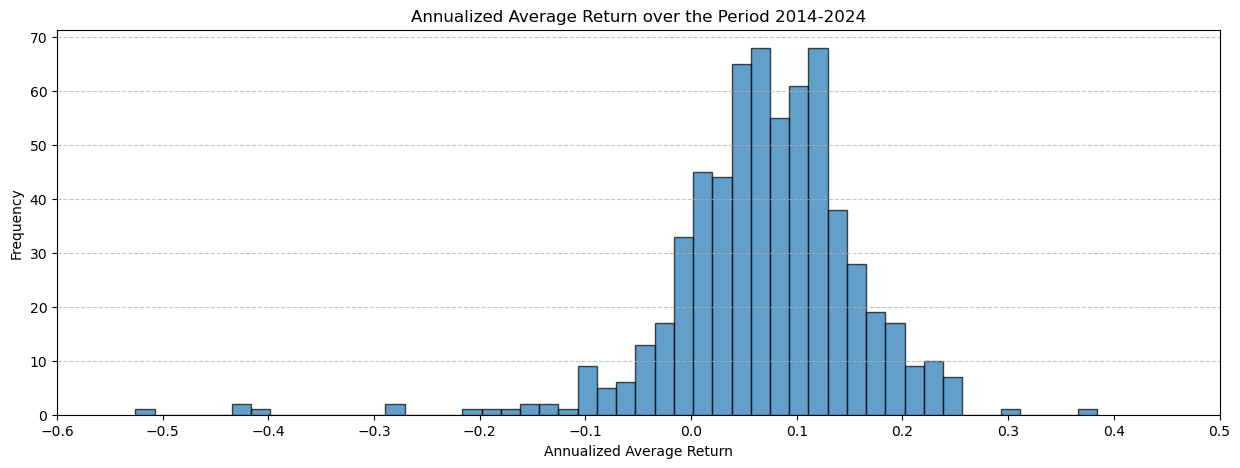

In [29]:
# plot the histogram of annualized average return
plt.figure(figsize = (15, 5))
plt.hist(ann_avg_r, bins=50, edgecolor="black", alpha=0.7)
plt.title("Annualized Average Return over the Period 2014-2024")
plt.xlabel("Annualized Average Return")
plt.ylabel("Frequency")
plt.xticks(np.arange(-0.6, 0.6, step=0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

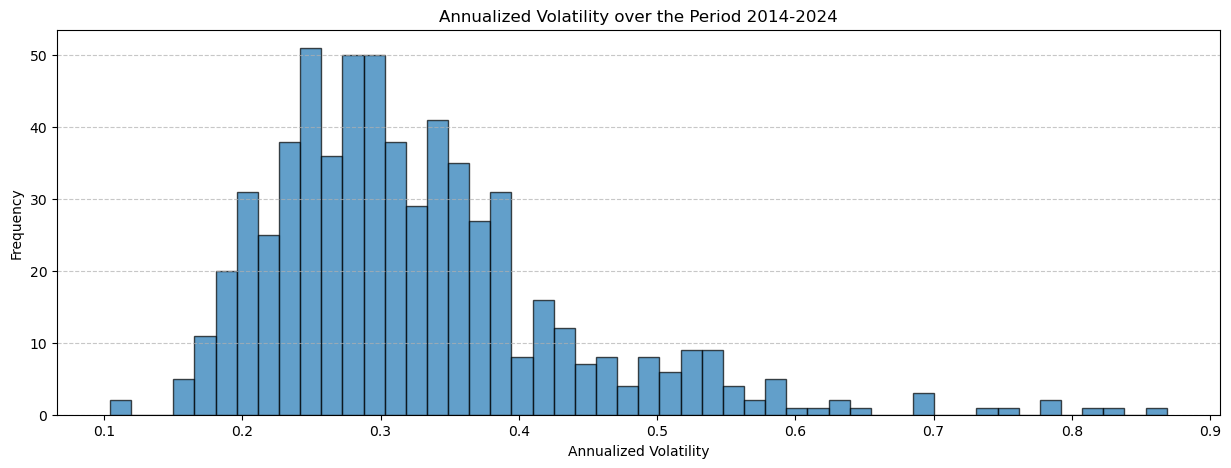

In [30]:
# plot the histogram of annualized volatility
plt.figure(figsize = (15, 5))
plt.hist(ann_vol, bins=50, edgecolor="black", alpha=0.7)
plt.title("Annualized Volatility over the Period 2014-2024")
plt.xlabel("Annualized Volatility")
plt.ylabel("Frequency")
plt.xticks(np.arange(0.1, 1, step=0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Correlation

In [31]:
# Compute the correlation between individual average return and volatilities in the corss section
df_corr = pd.DataFrame({'ann_avg_r': ann_avg_r, 'ann_vol': ann_vol})
correlation = df_corr.corr().iloc[0, 1]
print(correlation)

-0.23200064744522314


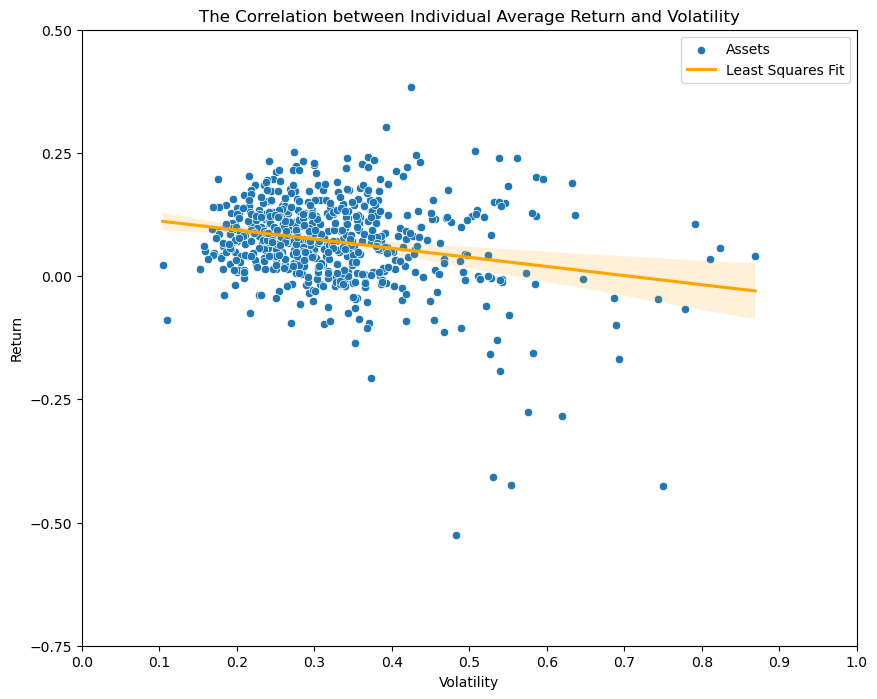

In [32]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=ann_vol, y=ann_avg_r)
sns.regplot(x=ann_vol, y=ann_avg_r, scatter=False, color="orange")

plt.title("The Correlation between Individual Average Return and Volatility")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.xticks(np.arange(0, 1.1, step=0.1))
plt.yticks(np.arange(-0.75, 0.75, step=0.25))
plt.legend(['Assets', 'Least Squares Fit'])
plt.show()


# Q2

## Portfolio 1: Equally weighted portfolio

In [33]:
R_m_p1 = temp1424.mean(axis=0)

In [34]:
# define a function to compute the properties of the portfolio
def portfolio_properties(r_tmp): # r is a dataframe
    # return
    ann_avg_r_tmp = np.mean(r_tmp) * 12 
    # volatility
    ann_vol_tmp = (r_tmp.std() * np.sqrt(12))[0]
    # Sharpe ratio
    excess_r_tmp = r_tmp - RF_m_temp
    ann_sr_tmp = (excess_r_tmp.mean() * 12 / (excess_r_tmp.std() * np.sqrt(12)))[0]
    # min
    min_tmp = r_tmp.min()[0]
    max_tmp = r_tmp.max()[0]
    # print
    print(f"Annualized average return: {ann_avg_r_tmp}")
    print(f"Annualized volatility: {ann_vol_tmp}") 
    print(f"Sharpe ratio: {ann_sr_tmp}")
    print(f"Minimum return: {min_tmp}")
    print(f"Maximum return: {max_tmp}")
    return ann_avg_r_tmp, ann_vol_tmp, ann_sr_tmp, min_tmp, max_tmp

In [35]:
# calculate the properties of the portfolio
R_m_p1 = pd.DataFrame(R_m_p1)
R_m_p1.index = RF_m_temp.index
ann_avg_r_p1, ann_vol_p1, ann_sr_p1, R_m_p1_min, R_m_p1_max = portfolio_properties(R_m_p1)


Annualized average return: 0.07040525122962812
Annualized volatility: 0.18789442263567643
Sharpe ratio: 0.2933173647811597
Minimum return: -0.23072512449673982
Maximum return: 0.23322467445977815


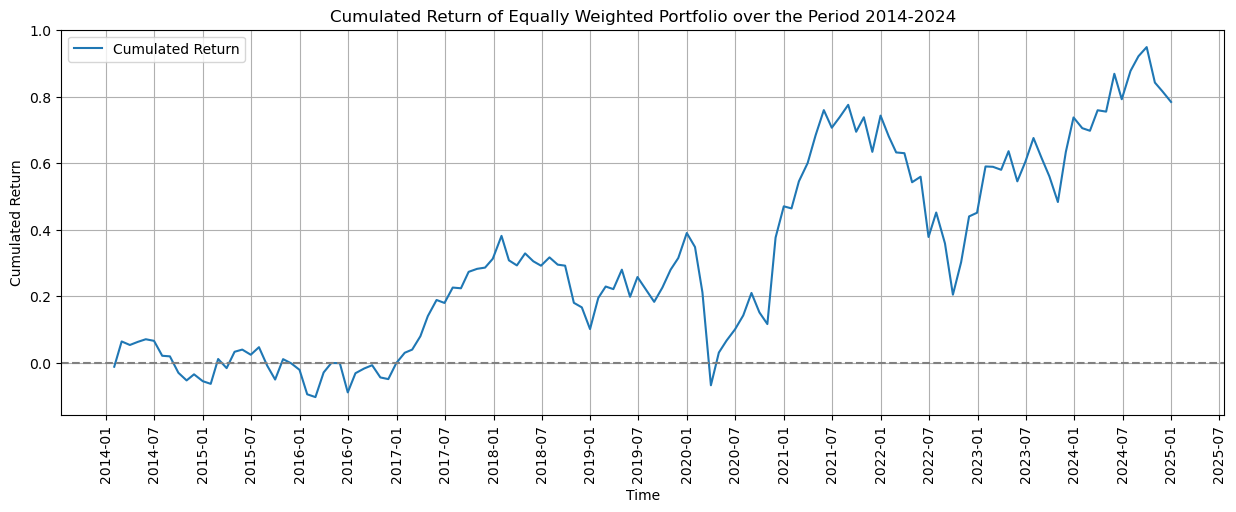

In [36]:
# cumulated returns
cum_r_m_p1 = np.cumprod(1 + R_m_p1) - 1

plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1, label="Cumulated Return")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Equally Weighted Portfolio over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()


## Portfolio 2: Market-cap weighted portfolio

In [37]:
mc_weight_p2 = temp1424_mc.div(temp1424_mc.sum(axis=0), axis=1)
R_m_p2 = (temp1424 * mc_weight_p2).sum(axis=0)

In [38]:
# calculate the properties of the portfolio
R_m_p2 = pd.DataFrame(R_m_p2)
R_m_p2.index = RF_m_temp.index
ann_avg_r_p2, ann_vol_p2, ann_sr_p2, R_m_p2_min, R_m_p2_max = portfolio_properties(R_m_p2)

Annualized average return: 0.10550168928248657
Annualized volatility: 0.16027493812260835
Sharpe ratio: 0.563286710369026
Minimum return: -0.13206904987646728
Maximum return: 0.19235741813082002


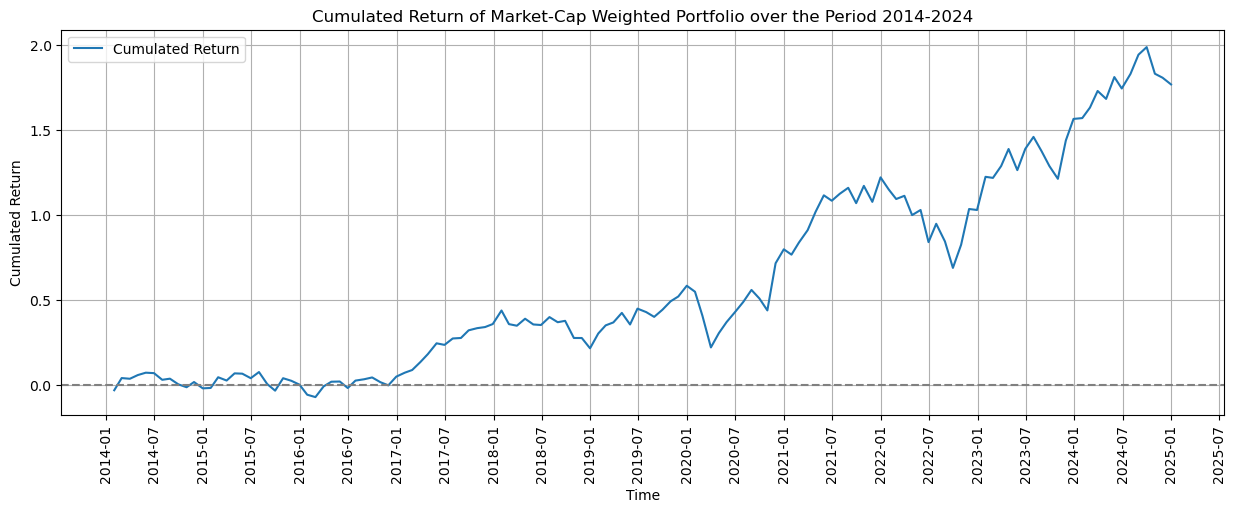

In [39]:
# cumulated returns
cum_r_m_p2 = np.cumprod(1 + R_m_p2) - 1

plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p2, label="Cumulated Return")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Market-Cap Weighted Portfolio over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()

## Comparison

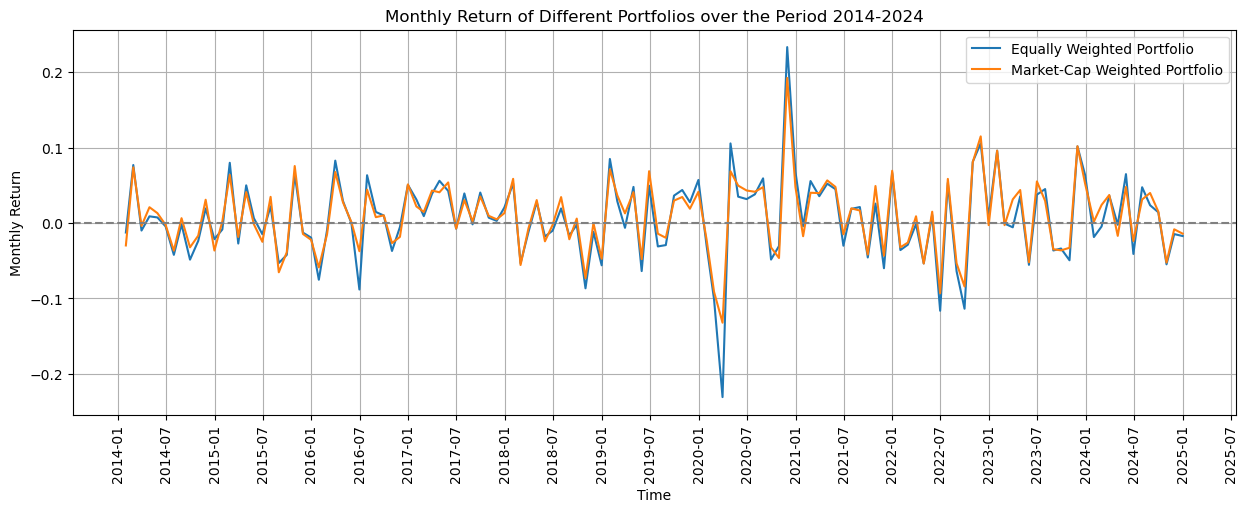

In [40]:
# plot monthly return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(R_m_p1, label="Equally Weighted Portfolio")
plt.plot(R_m_p2, label="Market-Cap Weighted Portfolio")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Monthly Return")
plt.title("Monthly Return of Different Portfolios over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()

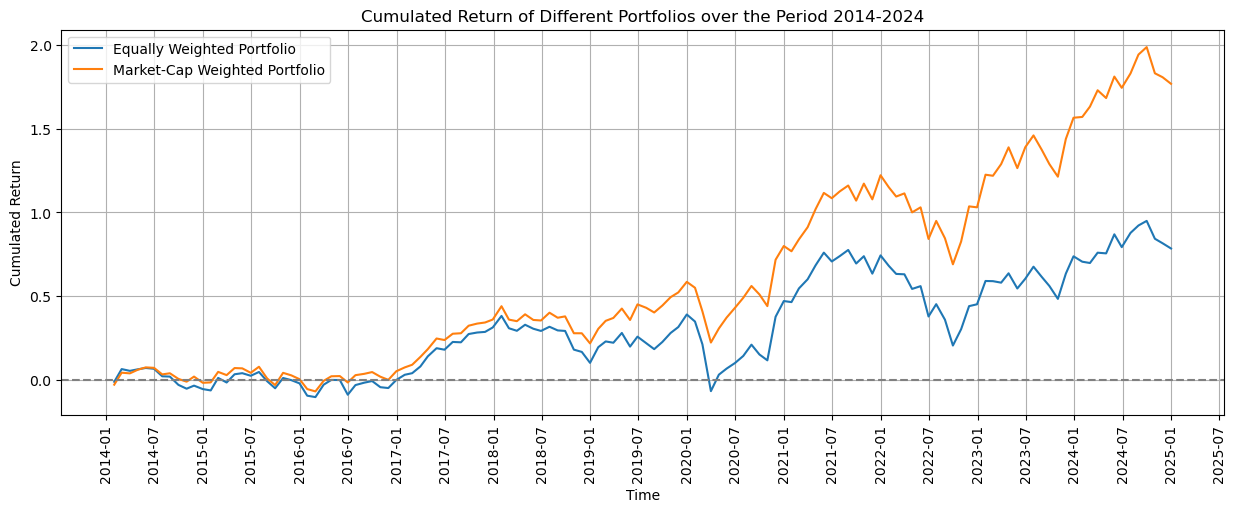

In [41]:
# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1, label="Equally Weighted Portfolio")
plt.plot(cum_r_m_p2, label="Market-Cap Weighted Portfolio")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()

# Q3

In [42]:
# compute the expected return
expected_r = temp1424.mean(axis=1)
ann_expected_r = expected_r.values.reshape((-1, 1)) * 12

In [43]:
# compute the population covariance matrix 
pop_cov = temp1424.T.cov(ddof=0)
ann_pop_cov = pop_cov * 12 

# N > T -> correct the non-positive denifite singular matrix
t = temp1424.shape[1]
pop_cov_fixed = LedoitWolf().fit(temp1424.T).covariance_ * (t-1) / t #fixed monthly covariance matrix

In [44]:
# compute the minimum variance portfolio
n = len(temp1424)

alpha1 = cp.Variable((n, 1))
objective_min_var = cp.Minimize(cp.quad_form(alpha1, pop_cov_fixed))
constraints_min_var = [cp.sum(alpha1) == 1, alpha1 >= 0]

prob_min_var = cp.Problem(objective_min_var, constraints_min_var)
prob_min_var.solve(solver=cp.GUROBI)

min_var_weights = alpha1.value
min_var_return = np.matmul(min_var_weights.T, ann_expected_r)[0][0]
min_var_return

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2630708
Academic license 2630708 - for non-commercial use only - registered to yo___@epfl.ch


0.026539928277618936

In [45]:
# compute the maximum return portfolio
alpha2 = cp.Variable((n, 1))
objective_max_r = cp.Maximize(cp.matmul(alpha2.T, ann_expected_r))
constraints_max_r = [cp.sum(alpha2) == 1, alpha2 >= 0]

prob_max_r = cp.Problem(objective_max_r, constraints_max_r)
prob_max_r.solve(solver=cp.GUROBI)

max_r_weights = alpha2.value 
max_r_return = np.matmul(max_r_weights.T, ann_expected_r)[0][0]
max_r_return

0.3839995896689018

In [46]:
# build the efficient frontier
target_returns = np.linspace(min_var_return, max_r_return, num=20)
efficient_frontier = []

for mu_p in tqdm(target_returns):
    alpha3 = cp.Variable((n, 1))
    objective_ef = cp.Minimize(cp.quad_form(alpha3, pop_cov_fixed))
    constraints_ef = [
        cp.matmul(alpha3.T, ann_expected_r) >= mu_p,
        cp.sum(alpha3) == 1,
        alpha3 >= 0,
    ]
    prob_ef = cp.Problem(objective_ef, constraints_ef)
    prob_ef.solve(solver=cp.GUROBI)

    mu_ante = np.matmul(alpha3.value.T, ann_expected_r)[0][0]
    # mu_ante = (alpha3.value.T @ temp1424.values).mean() * 12
    vol_ef = np.sqrt(alpha3.value.T @ ann_pop_cov @ alpha3.value)
    efficient_frontier.append(
        {"mu": mu_ante, "vol": vol_ef[0][0], "weight": alpha3.value.flatten()}
    )

100%|██████████| 20/20 [00:08<00:00,  2.30it/s]


In [47]:
ann_expected_r

array([[ 1.27820172e-01],
       [ 1.36039287e-01],
       [ 5.92846643e-02],
       [ 1.48043524e-01],
       [ 7.76975192e-02],
       [ 5.43872645e-02],
       [ 9.09660871e-02],
       [ 1.84207215e-01],
       [ 1.25701131e-01],
       [ 2.47461090e-02],
       [ 5.68792348e-03],
       [ 9.21129939e-03],
       [-3.29842224e-03],
       [ 1.73931397e-01],
       [ 5.33207001e-02],
       [ 1.01603278e-01],
       [-3.80230705e-03],
       [ 1.09279965e-01],
       [ 1.97547572e-02],
       [ 1.31004326e-01],
       [-4.40368676e-02],
       [ 1.49671143e-02],
       [-7.40787253e-02],
       [ 9.22623542e-02],
       [ 1.42427466e-02],
       [ 7.46883107e-02],
       [ 8.17535357e-02],
       [ 1.33786980e-01],
       [-1.54374607e-02],
       [-3.85001424e-03],
       [ 2.12201175e-01],
       [ 1.05615796e-01],
       [-3.38479893e-02],
       [ 8.99881928e-02],
       [ 5.99826443e-02],
       [ 9.29474996e-02],
       [ 1.44193507e-01],
       [ 1.40140286e-01],
       [-2.1

In [48]:
mus = [item["mu"] for item in efficient_frontier]
vols = [item["vol"] for item in efficient_frontier]
weights = [item["weight"] for item in efficient_frontier]

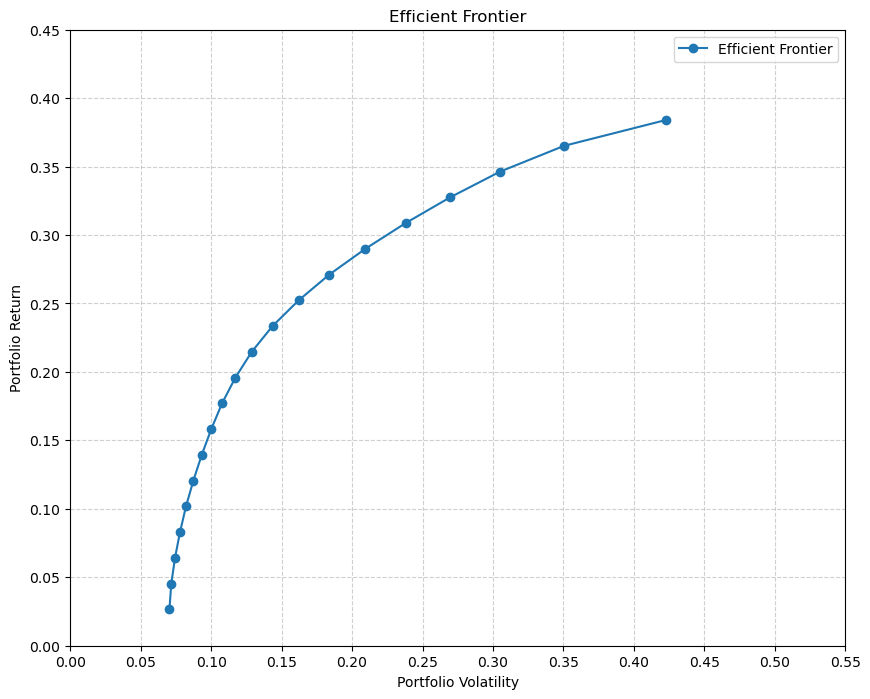

In [49]:
# Plot the efficient frontier alone
plt.figure(figsize=(10, 8))
plt.plot(vols, mus, 'o-', label="Efficient Frontier")
plt.title('Efficient Frontier')
plt.xlabel("Portfolio Volatility")
plt.ylabel("Portfolio Return")
plt.xticks(np.arange(0, 0.6, step=0.05))
plt.yticks(np.arange(0, 0.5, step=0.05))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [50]:
# compute the ex-post performance
R_m_p3 = []

for weight in weights:
    weight = weight.reshape((1, -1))
    ex_post_r = weight @ temp1424.values
    R_m_p3.append(ex_post_r)


In [51]:
# check whether the weights are positive
[np.sum(weight < 0) for weight in weights]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [52]:
np.max(R_m_p3[0])

0.05361256193972409

In [53]:
# compute the ex-post annualized average return, the ex-post annualized volatility, and the ex-post annualized Sharpe ratio
ann_rf = (RF_m_temp.mean() * 12)[0]
ann_avg_r_ef_post = []
ann_vol_ef_post = []
ann_sp_ef_post = []

for portfolio in R_m_p3:
    r = portfolio.mean() * 12
    ann_avg_r_ef_post.append(r)
    vol = portfolio.std() * np.sqrt(12)
    ann_vol_ef_post.append(vol)
    # e_r = portfolio - RF_m_temp.values
    # sp = (e_r.mean() * 12 / (e_r.std() * np.sqrt(12)))
    sp = (r - ann_rf) / vol
    ann_sp_ef_post.append(sp)

print(f"Ex-post annualized average return: {ann_avg_r_ef_post}")
print(f"Ex-post annualized volatility: {ann_vol_ef_post}")
print(f"Ex-post annualized Sharpe ratio: {ann_sp_ef_post}")


Ex-post annualized average return: [0.02662073265481446, 0.04535360067888286, 0.06416726715438732, 0.08298092772356741, 0.10179459441505329, 0.12060826049452256, 0.13942192662164127, 0.15823559344624796, 0.17704925942803182, 0.1958629258123255, 0.2146765921761581, 0.2334902586013362, 0.2523039251355806, 0.2711175913351421, 0.2899312580052834, 0.3087449241458289, 0.32755859053913283, 0.3463722568915774, 0.36518592328173455, 0.3839995896793427]
Ex-post annualized volatility: [0.07036568497701313, 0.07167886466815918, 0.07432150139161184, 0.07786275909331604, 0.08212629857928164, 0.08733878735294841, 0.09329789738093776, 0.10006220151666695, 0.10769510326726746, 0.1171766792334765, 0.12875363394171152, 0.1435253355378014, 0.16205776848407574, 0.18379917863292253, 0.20937646643403596, 0.23797969612287903, 0.26959065265439386, 0.3050855760326452, 0.3504695214601163, 0.4225806192933171]
Ex-post annualized Sharpe ratio: [0.161271866902089, 0.4196616889150863, 0.6578787963933469, 0.86958388373

In [54]:
# compute the ex-ante Sharpe ratio
ann_sp_ef_ante = []

for item in efficient_frontier:
    mu = item["mu"]
    vol = item["vol"]
    sp_ante = (mu - ann_rf) / vol
    ann_sp_ef_ante.append(sp_ante)

print(f"Ex-ante return: {mus}")
print(f"Ex-ante volatility: {vols}")
print(f"Ex-ante annualized Sharpe ratio: {ann_sp_ef_ante}")

# Note: It makes sense that the ex-ante and ex-post results are super close, because the calculations of expected return and covariance matrix are based on the real data during sample period rather than predictions.

Ex-ante return: [0.0266207326548145, 0.04535360067888289, 0.06416726715438735, 0.08298092772356742, 0.10179459441505323, 0.12060826049452254, 0.13942192662164135, 0.1582355934462481, 0.17704925942803185, 0.1958629258123255, 0.21467659217615806, 0.23349025860133638, 0.2523039251355806, 0.2711175913351423, 0.2899312580052835, 0.3087449241458289, 0.327558590539133, 0.34637225689157736, 0.3651859232817347, 0.3839995896793426]
Ex-ante volatility: [0.07036568497701313, 0.07167886466815918, 0.07432150139161187, 0.07786275909331604, 0.08212629857928164, 0.08733878735294844, 0.09329789738093777, 0.10006220151666698, 0.10769510326726744, 0.11717667923347652, 0.12875363394171152, 0.1435253355378014, 0.16205776848407577, 0.1837991786329225, 0.20937646643403587, 0.23797969612287903, 0.2695906526543938, 0.305085576032645, 0.3504695214601166, 0.4225806192933163]
Ex-ante annualized Sharpe ratio: [0.16127186690208956, 0.41966168891508665, 0.657878796393347, 0.8695838837369484, 1.0535220585742215, 1.206

In [55]:
# Compare the ex-ante and ex-post performance in a table
portfolio_name = np.arange(1, 21, 1)
ante_post_comparison = pd.DataFrame(
    {'Portfolio': portfolio_name,
     'Ex-Ante Return': mus,
     'Ex_Ante Volatility': vols,
     'Ex-Ante Sharpe Ratio': ann_sp_ef_ante,
     'Ex-Post Return': ann_avg_r_ef_post,
     'Ex-Post Volatility': ann_vol_ef_post,
     'Ex-Post Sharpe Ratio': ann_sp_ef_post
    }
)

ante_post_comparison

,Portfolio,Ex-Ante Return,Ex_Ante Volatility,Ex-Ante Sharpe Ratio,Ex-Post Return,Ex-Post Volatility,Ex-Post Sharpe Ratio
0,1,0.026621,0.070366,0.161272,0.026621,0.070366,0.161272
1,2,0.045354,0.071679,0.419662,0.045354,0.071679,0.419662
2,3,0.064167,0.074322,0.657879,0.064167,0.074322,0.657879
3,4,0.082981,0.077863,0.869584,0.082981,0.077863,0.869584
4,5,0.101795,0.082126,1.053522,0.101795,0.082126,1.053522
5,6,0.120608,0.087339,1.206057,0.120608,0.087339,1.206057
6,7,0.139422,0.093298,1.330675,0.139422,0.093298,1.330675
7,8,0.158236,0.100062,1.428740,0.158236,0.100062,1.428740
8,9,0.177049,0.107695,1.502172,0.177049,0.107695,1.502172
9,10,0.195863,0.117177,1.541179,0.195863,0.117177,1.541179


In [56]:
# Compare the performance in terms of ex-ante Sharpe ratio & ex-post Sharpe ratio
print(f"Index of the portfolio with the highest performance in terms of ex-ante Sharpe ratio: {np.argmax(ann_sp_ef_ante)}")
print(f"Index of the portfolio with the highest performance in terms of ex-post Sharpe ratio: {np.argmax(ann_sp_ef_post)}")  

# From the output, we can see that the 11th portfolio has the best performance

Index of the portfolio with the highest performance in terms of ex-ante Sharpe ratio: 10
Index of the portfolio with the highest performance in terms of ex-post Sharpe ratio: 10


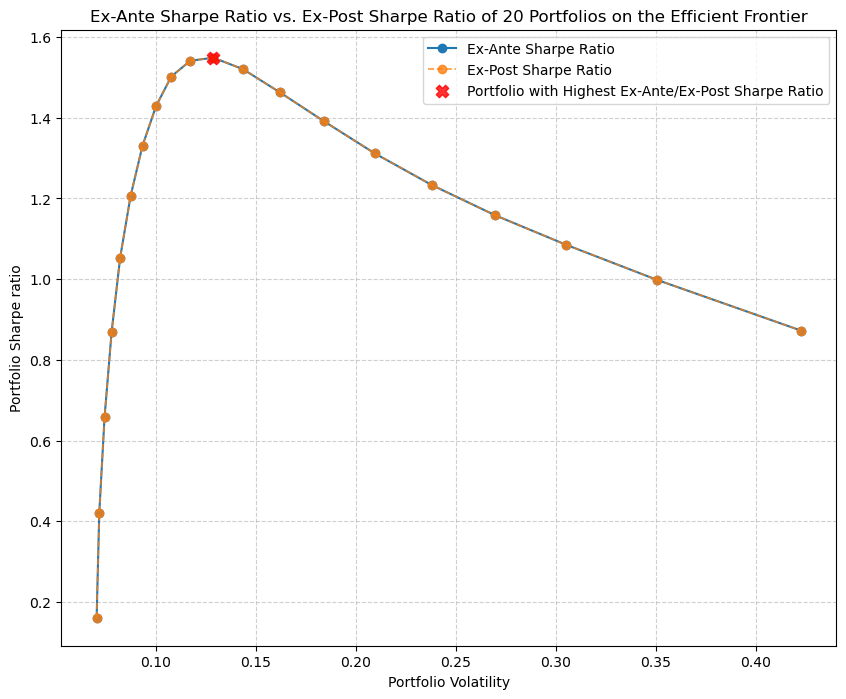

In [57]:
plt.figure(figsize=(10, 8))
plt.plot(vols, ann_sp_ef_ante, 'o-', label="Ex-Ante Sharpe Ratio")
plt.plot(ann_vol_ef_post, ann_sp_ef_post, 'o--', label="Ex-Post Sharpe Ratio", alpha=0.8, linewidth=1.2)
plt.scatter(ann_vol_ef_post[10], ann_sp_ef_post[10], color="red", marker="X", s=80, label="Portfolio with Highest Ex-Ante/Ex-Post Sharpe Ratio", alpha=0.8, zorder=3)
plt.title('Ex-Ante Sharpe Ratio vs. Ex-Post Sharpe Ratio of 20 Portfolios on the Efficient Frontier')
plt.xlabel("Portfolio Volatility")
plt.ylabel("Portfolio Sharpe ratio")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

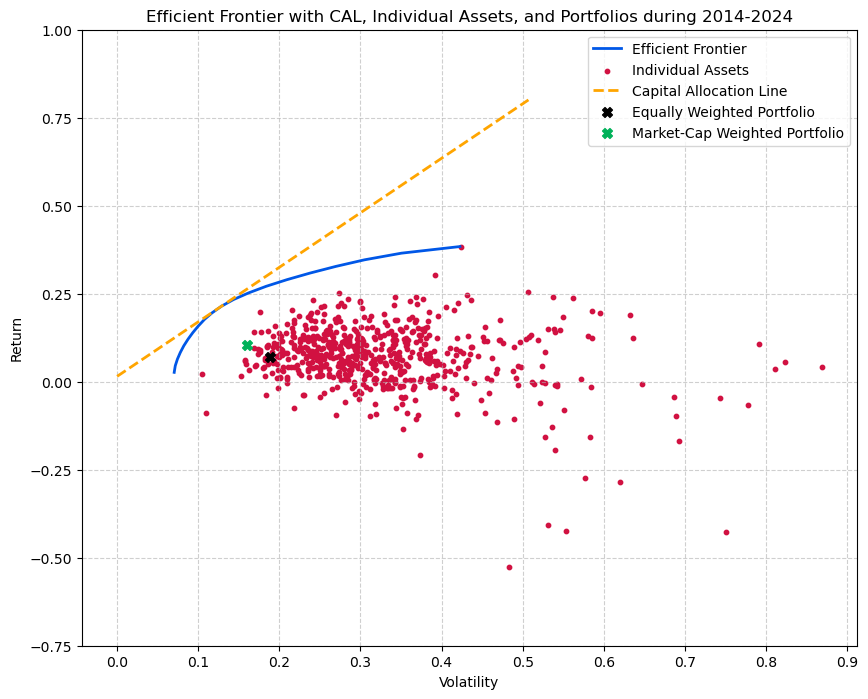

In [58]:
cal_slope = np.max(ann_sp_ef_ante)
cal_vol = np.linspace(0, max(vols) * 1.2, 100)
cal_r = ann_rf + cal_slope * cal_vol

plt.figure(figsize=(10, 8))
plt.plot(vols, mus, label="Efficient Frontier", color="#0057e7", linestyle="-", linewidth=2)
plt.scatter(ann_vol, ann_avg_r, color="#d11141", marker="o", label="Individual Assets", s=10)
plt.plot(cal_vol, cal_r, color="orange", linestyle="--", label="Capital Allocation Line", linewidth=2)
plt.scatter(ann_vol_p1, ann_avg_r_p1, color="black", marker="X", s=50, label="Equally Weighted Portfolio")
plt.scatter(ann_vol_p2, ann_avg_r_p2, color="#00b159", marker="X", s=50, label="Market-Cap Weighted Portfolio")

plt.title('Efficient Frontier with CAL, Individual Assets, and Portfolios during 2014-2024')
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.xticks(np.arange(0, 1, step=0.1))
plt.yticks(np.arange(-0.75, 1.25, step=0.25))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Q4

In [59]:
# compute the expected returns and the covariance matrix (out of sample) for 2014-2024 (yearly)
mu1424 = (temp0424.T.rolling(window=120, step=12).mean() * 12).T #annualized expected return
mu1424 = mu1424.loc[:, mu1424.columns >= pd.Timestamp("2014-01-01")].copy()

tau = 120
step = 12
start_index = [i for i in range(0, 121, 12)]
weights_gmv = []
R_m_gmv = []

# compute the optimal weight
for start in start_index:
    df = temp0424.iloc[:, start:(start+tau)]
    cov_df = df.T.cov(ddof=0) * 12 # annualized covariance matrix
    cov_df_fixed = LedoitWolf().fit(df.T).covariance_ * (tau - 1) / tau  #fixed monthly covariance matrix

    alpha_df = cp.Variable((n,1))
    objective_rw = cp.Minimize(cp.quad_form(alpha_df, cov_df_fixed))
    constraints_rw = [cp.sum(alpha_df) == 1, alpha_df >= 0]

    prob_rw = cp.Problem(objective_rw, constraints_rw)
    prob_rw.solve(solver=cp.GUROBI)

    alpha_df = alpha_df.value.reshape((1, -1))
    weights_gmv.append(alpha_df)

    # compute the portfolio return for the Jan of each year
    r_p_jan = (alpha_df @ temp1424.iloc[:, start].values.reshape((-1, 1)))[0][0]
    R_m_gmv.append(r_p_jan)

    alpha_df_temp = alpha_df.copy()
    r_p_temp = r_p_jan
    # update the monthly weight
    for i in range(1, 12):
        r = temp1424.iloc[:, start+i-1].values.reshape((-1, 1))
        update_coef = ((r + 1) / (1 + r_p_temp)).T  # shape: (1, n)
        alpha_df_temp = alpha_df_temp * update_coef
        weights_gmv.append(alpha_df_temp)

        r_p_temp = (alpha_df_temp @ temp1424.iloc[:, start+i].values.reshape((-1, 1)))[0][0]
        R_m_gmv.append(r_p_temp)


In [60]:
# a time series of ex-post portfolio monthly return
R_m_gmv

[-0.0119046283354555,
 0.04461537474148946,
 0.0017994930217162144,
 0.0017937133676403172,
 -0.00747833260294321,
 -0.0047728208552577575,
 -0.0008652336108722315,
 0.0007233196364119427,
 -0.03970348624228806,
 -0.014853233202140688,
 -0.006436738079094207,
 -0.01760527098538927,
 -0.013291610926507927,
 0.07351603287500931,
 -0.02758972723740135,
 0.02199144600299962,
 -0.0008832680068651316,
 -0.008635814202630867,
 0.0180219964903822,
 -0.02397663068350438,
 -0.003931269083666497,
 0.03207867733538566,
 -0.0033087189359335464,
 -0.014625331239996668,
 -0.01639987194077167,
 -0.008964225279467334,
 0.024211334579853236,
 0.008342202038338077,
 0.00027456148086184886,
 -0.0030834272658903914,
 0.016491187027152885,
 -0.007781742117623529,
 0.011229415291577454,
 -0.006044785170612084,
 0.0019152416892924125,
 0.00656305637943228,
 0.003412317868126844,
 0.011600192679782961,
 0.008997894493211131,
 0.018326560796881573,
 0.01772797449769663,
 0.00913572346458462,
 0.0120011352467592

In [61]:
# compute the properties of the portfolio
R_m_gmv = pd.DataFrame(R_m_gmv)
R_m_gmv.index = RF_m_temp.index
ann_avg_r_gmv, ann_vol_gmv, ann_sr_gmv, R_m_gmv_min, R_m_gmv_max = portfolio_properties(R_m_gmv)

Annualized average return: 0.019852887979264544
Annualized volatility: 0.09877079717505154
Sharpe ratio: 0.04634962296953724
Minimum return: -0.10922668639596568
Maximum return: 0.08945783172044916


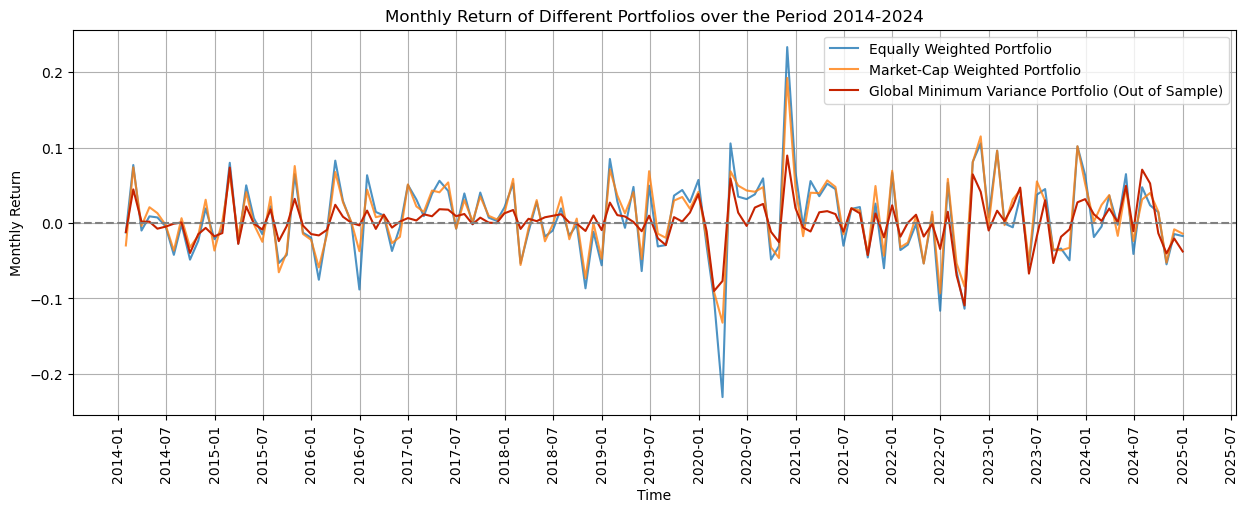

In [62]:
# plot monthly return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(R_m_p1, label="Equally Weighted Portfolio", alpha=0.8)
plt.plot(R_m_p2, label="Market-Cap Weighted Portfolio", alpha=0.8)
plt.plot(R_m_gmv, color="#C62300", label="Global Minimum Variance Portfolio (Out of Sample)")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Monthly Return")
plt.title("Monthly Return of Different Portfolios over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()

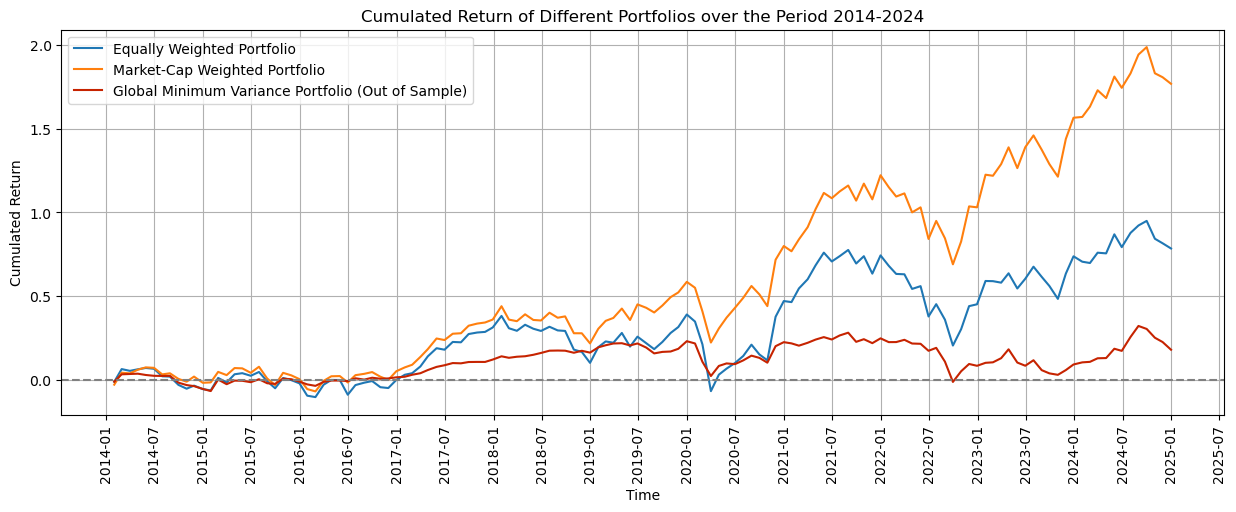

In [63]:
cum_r_m_gmv = np.cumprod(1 + R_m_gmv) - 1

# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1, label="Equally Weighted Portfolio")
plt.plot(cum_r_m_p2, label="Market-Cap Weighted Portfolio")
plt.plot(cum_r_m_gmv, color="#C62300", label="Global Minimum Variance Portfolio (Out of Sample)")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2024")
plt.legend()
plt.grid(True)
plt.show()

# HW2

# Q1

In [64]:
# cross-sectional summary statistics over 1999-2023
summary_statistics_GScore = GScore_9923.describe().T
summary_statistics_GScore = summary_statistics_GScore[["mean", "50%", "min", "max", "std"]].rename(columns={'50%': 'median'})

summary_statistics_GScore = summary_statistics_GScore.round(2)

summary_statistics_GScore


,mean,median,min,max,std
1999,54.87,55.50,4.78,92.90,16.02
2000,54.87,55.50,4.78,92.90,16.02
2001,54.87,55.50,4.78,92.90,16.02
2002,50.15,51.27,4.78,93.72,18.67
2003,50.42,51.76,3.16,98.37,18.84
2004,50.16,51.62,2.41,99.33,20.60
2005,48.20,47.93,1.33,98.86,21.72
2006,48.58,48.41,0.80,98.12,21.39
2007,49.72,49.93,3.11,99.04,21.51
2008,49.59,50.28,2.41,97.58,21.89


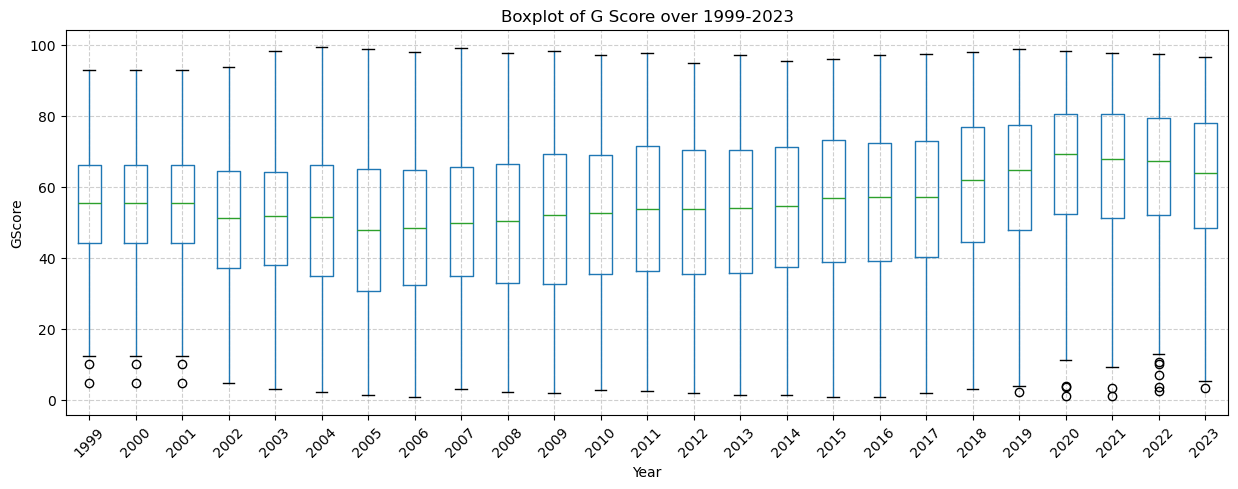

In [65]:
plt.figure(figsize=(15, 5))
GScore_9923.boxplot(grid=False)
plt.title('Boxplot of G Score over 1999-2023')
plt.xlabel('Year')
plt.ylabel('GScore')
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

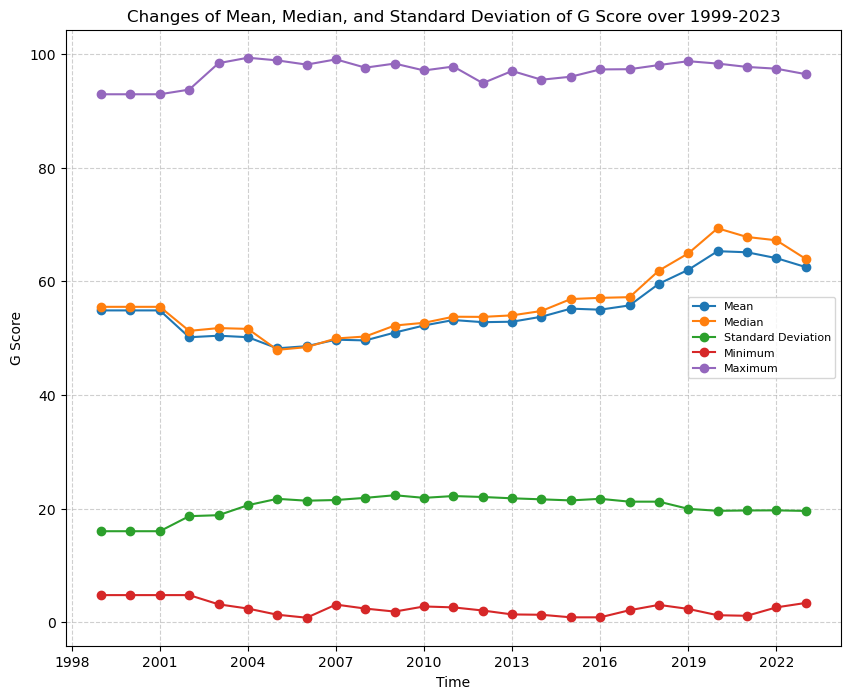

In [66]:
# visualize the changes of mean, median, and std
fig, ax = plt.subplots(figsize=(10, 8))    
plt.plot(summary_statistics_GScore['mean'], 'o-', label="Mean")
plt.plot(summary_statistics_GScore['median'], 'o-', label="Median")
plt.plot(summary_statistics_GScore['std'], 'o-', label="Standard Deviation")
plt.plot(summary_statistics_GScore['min'], 'o-', label="Minimum")
plt.plot(summary_statistics_GScore['max'], 'o-', label="Maximum")
plt.title('Changes of Mean, Median, and Standard Deviation of G Score over 1999-2023')
plt.xlabel("Time")
plt.ylabel("G Score")
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(prop={'size': 8})
plt.show()

/Users/maocheng/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/maocheng/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/maocheng/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/maocheng/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

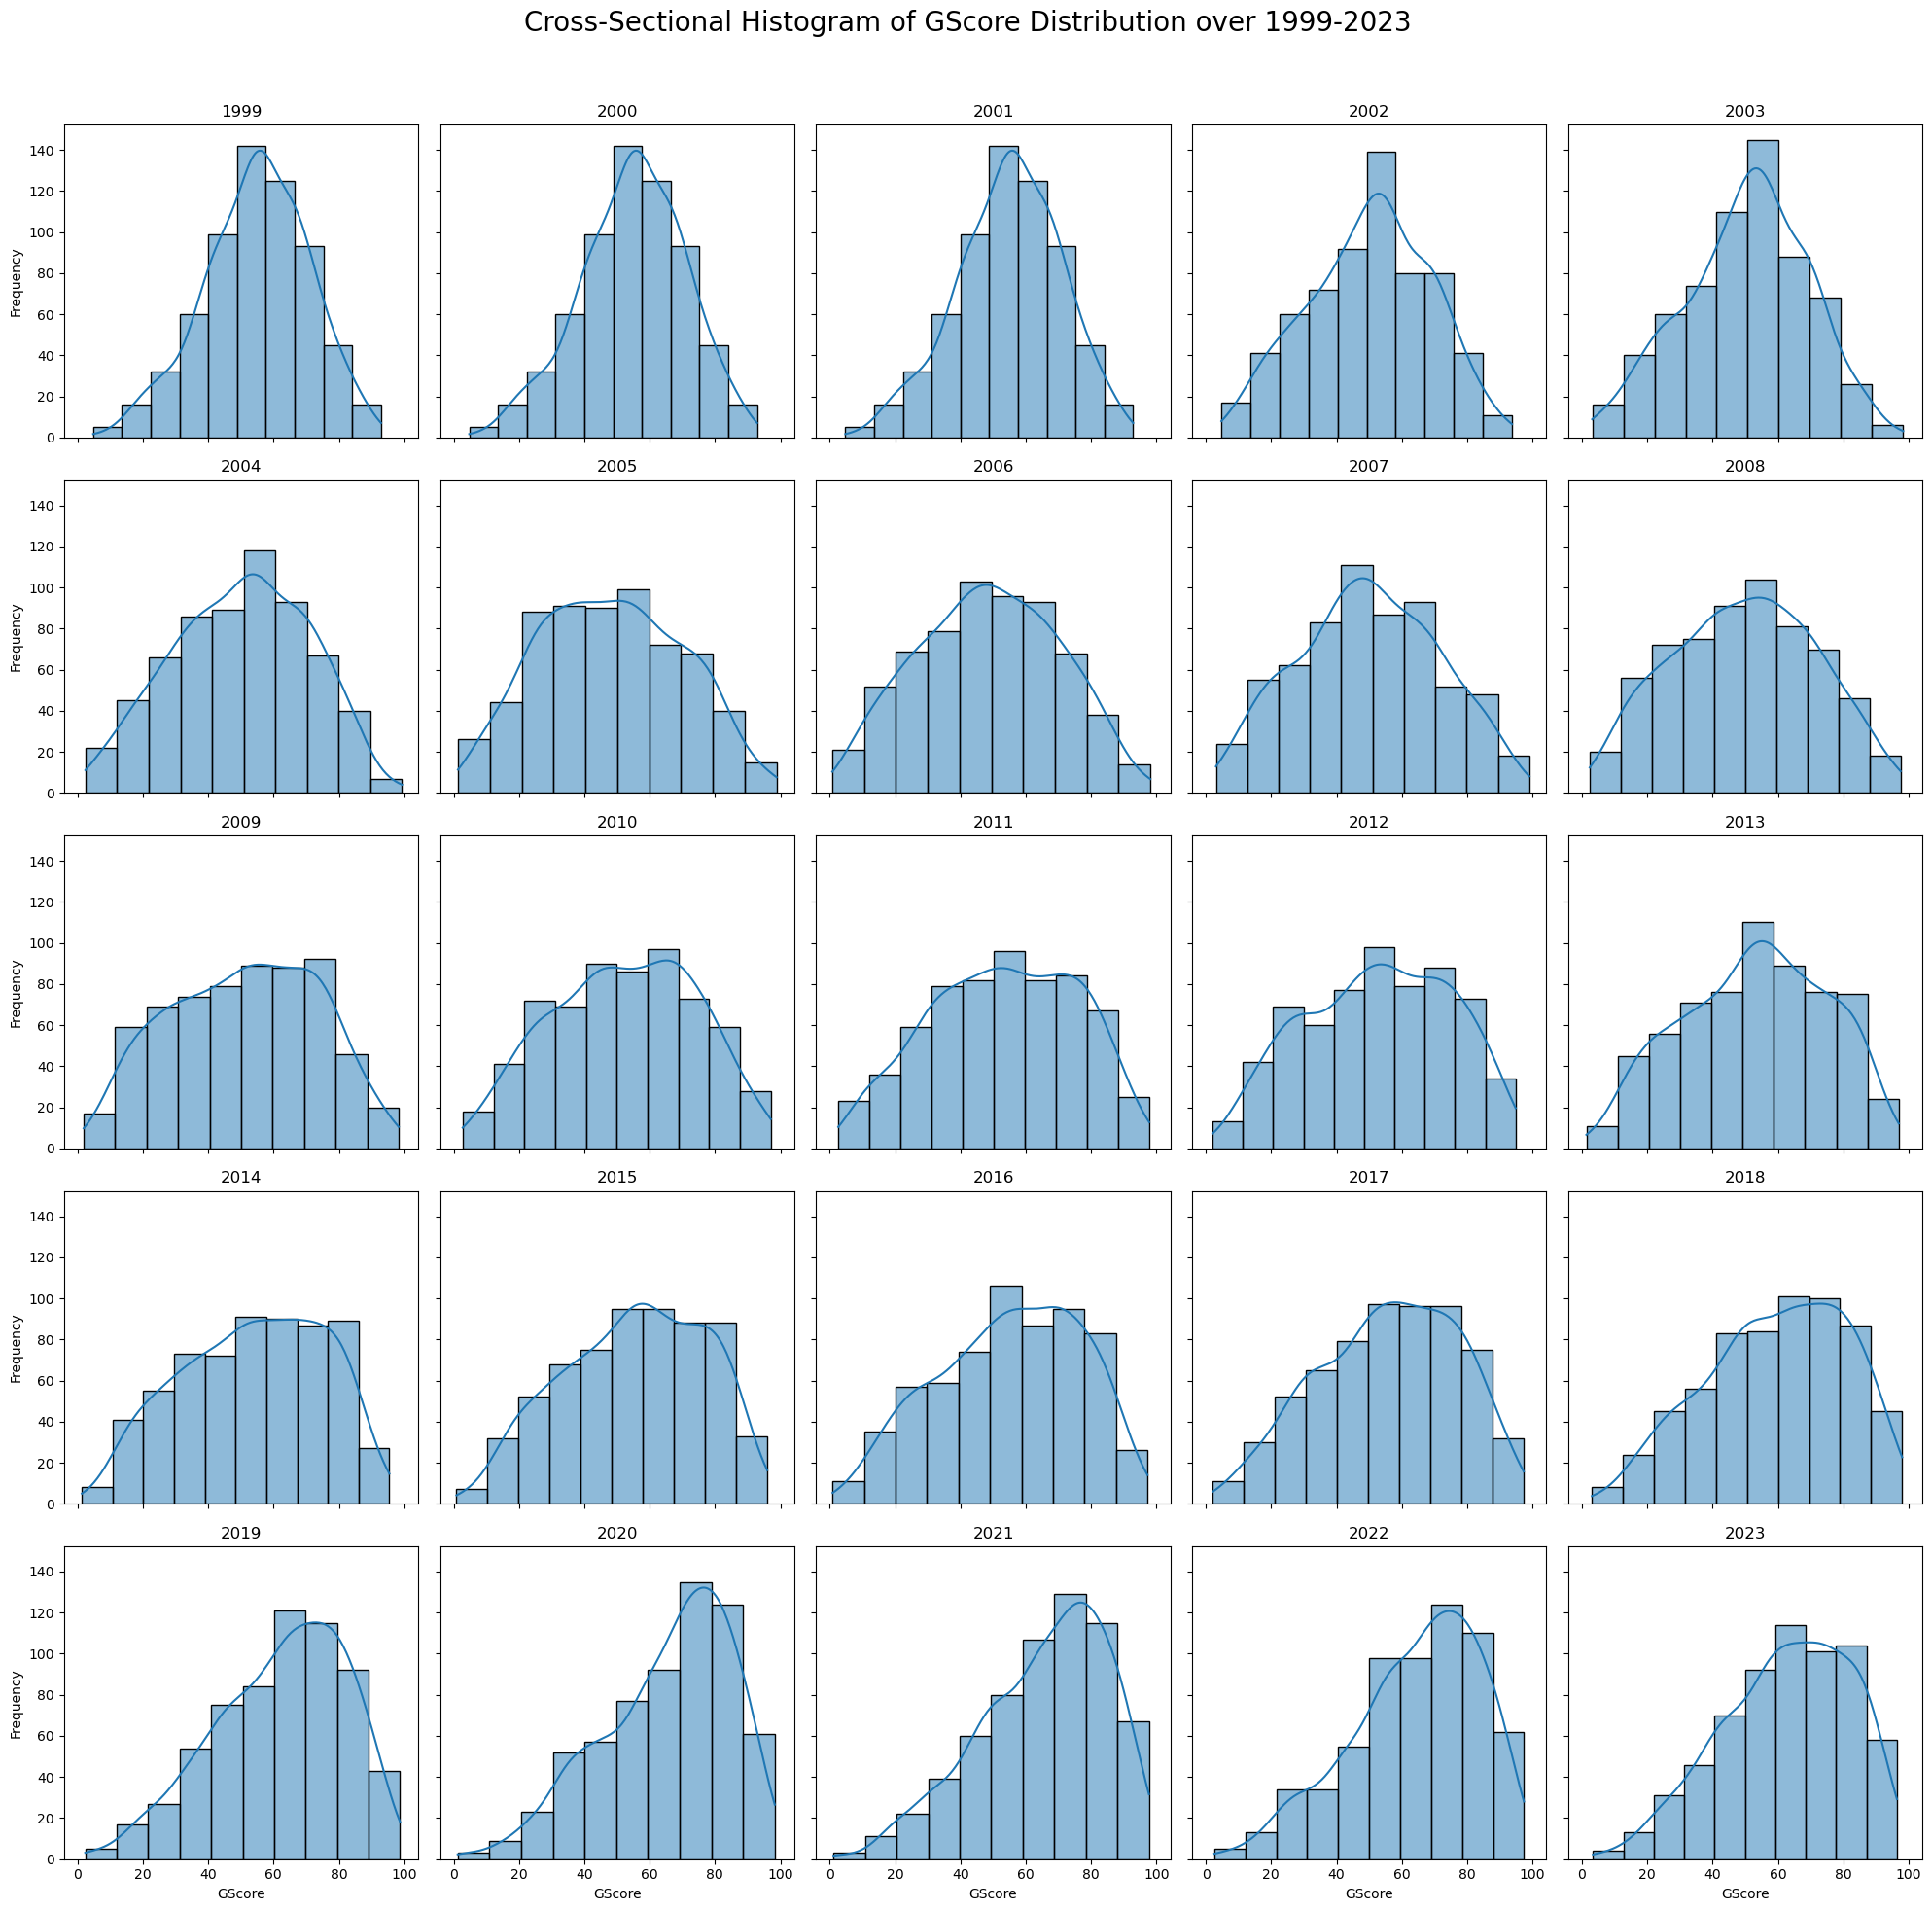

In [67]:
# draw the cross-sectional histogram of distribution of the score
fig, axes = plt.subplots(5, 5, figsize=(20, 20), sharex=True, sharey=True)

for i, (year, data) in enumerate(GScore_9923.items()):
    ax = axes[i // 5, i % 5]
    sns.histplot(data, bins=10, kde=True, ax=ax)
    # ax.axvline(np.mean(data), color='red', linestyle='dashed', label='mean')
    # ax.axvline(np.median(data), color='green', linestyle='dashed', label='median')
    # ax.legend()
    ax.set_title(f'{year}')
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[-1, :]:
    ax.set_xlabel('GScore')

for ax in axes[:, 0]:
    ax.set_ylabel('Frequency')


fig.suptitle('Cross-Sectional Histogram of GScore Distribution over 1999-2023', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [68]:
# summary statistic for all G Score (not cross-sectional)
GScore_9923_long = GScore_9923.melt(var_name="Year", value_name="GScore")
summary_statistics_GScore_all = GScore_9923_long["GScore"].describe()
summary_statistics_GScore_all

count    15825.000000
mean        54.867570
std         21.066880
min          0.800000
25%         39.800000
50%         56.050000
75%         71.311364
max         99.330000
Name: GScore, dtype: float64

/Users/maocheng/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


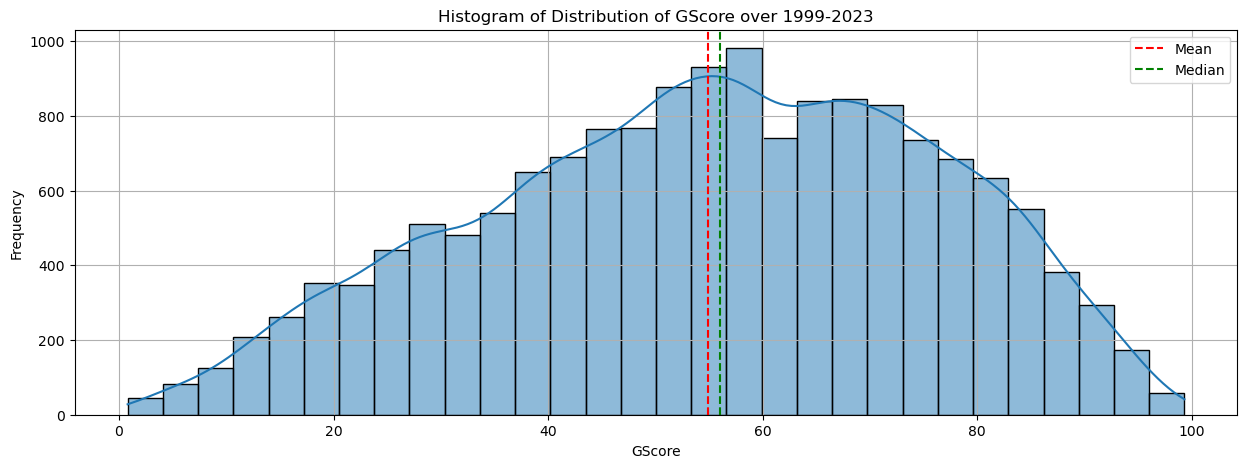

In [69]:
# draw the histogram of distribution of all G score
plt.figure(figsize=(15, 5))
sns.histplot(GScore_9923_long['GScore'], bins=30, kde=True)
plt.axvline(np.mean(GScore_9923_long['GScore']), color='red', linestyle='dashed', label='Mean')
plt.axvline(np.median(GScore_9923_long['GScore']), color='green', linestyle='dashed', label='Median')
plt.title('Histogram of Distribution of GScore over 1999-2023')
plt.xlabel('GScore')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Q2

In [70]:
# average GScore over 2014-2023 (sample period)
GScore_avg_1423 = GScore_1423.mean(axis=1)

# weighted average GScore
weights_ef = pd.DataFrame(weights)
GScore_ef = weights_ef @ GScore_avg_1423
GScore_ef

0     48.136994
1     48.176527
2     49.142719
3     50.291221
4     51.313765
5     51.767557
6     52.410984
7     54.173907
8     56.423836
9     57.487914
10    58.696291
11    60.340135
12    61.797486
13    61.676334
14    60.176746
15    58.011024
16    56.070149
17    53.847492
18    52.370767
19    50.432000
dtype: float64

In [71]:
# find the top 10 firms driving the GScore down

# in terms of individual average GScore
GScore_avg_withname = pd.concat([name_meta_633, GScore_avg_1423], axis=1).rename(columns={0: 'Average_GScore'})
GScore_avg_withname_sorted = GScore_avg_withname.sort_values(by='Average_GScore', ascending=True)

display(GScore_avg_withname_sorted.head(10))

,NAME,ISIN,Country,Average_GScore
518,DELEK GROUP,IL0010841281,IL,4.595000
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,6.128000
162,OBRASCON HUARTE LAIN,ES0142090317,ES,13.073333
161,FAES FARMA,ES0134950F36,ES,13.435778
17,SOFINA,BE0003717312,BE,16.867000
293,TOWN CENTRE SECURITIES,GB0003062816,GB,17.130000
262,ANGLO-EASTERN PLTNS.,GB0000365774,GB,17.357500
195,SECHE ENVIRONNEMENT,FR0000039109,FR,18.365000
70,FLUGHAFEN ZURICH,CH0319416936,CH,18.974364
512,FIRST INTL.BK.OF ISR.,IL0005930388,IL,19.195000


In [72]:
# in terms of each firm's contribution in each portfolio
GScore_ef_contribution = []

# calculate the contribution of each firm in 20 portfolios
for i in range(0,20):
    contribution_tmp = pd.DataFrame(weights_ef.iloc[i, :] * GScore_avg_1423)
    contribution_tmp = pd.concat([name_meta_633, contribution_tmp], axis=1).rename(columns={0: 'Contribution'})
    contribution_tmp_sorted = contribution_tmp.sort_values(by='Contribution', ascending=True)
    GScore_ef_contribution.append(contribution_tmp_sorted)
    print(f"Portfolio {i+1}")
    display(contribution_tmp_sorted.head(10))


Portfolio 1


,NAME,ISIN,Country,Contribution
518,DELEK GROUP,IL0010841281,IL,2.244492e-09
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,2.763633e-09
162,OBRASCON HUARTE LAIN,ES0142090317,ES,4.591330e-09
93,SALZGITTER,DE0006202005,DE,7.192961e-09
27,VIOHALCO,BE0974271034,BE,7.380313e-09
466,JD SPORTS FASHION,GB00BM8Q5M07,GB,7.930941e-09
293,TOWN CENTRE SECURITIES,GB0003062816,GB,8.302029e-09
555,WERELDHAVE,NL0000289213,NL,8.329823e-09
63,TRANSOCEAN,CH0048265513,CH,9.414604e-09
17,SOFINA,BE0003717312,BE,9.658146e-09


Portfolio 2


,NAME,ISIN,Country,Contribution
518,DELEK GROUP,IL0010841281,IL,2.893012e-08
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,2.906820e-08
162,OBRASCON HUARTE LAIN,ES0142090317,ES,4.008287e-08
93,SALZGITTER,DE0006202005,DE,6.581624e-08
27,VIOHALCO,BE0974271034,BE,7.116627e-08
293,TOWN CENTRE SECURITIES,GB0003062816,GB,7.953465e-08
466,JD SPORTS FASHION,GB00BM8Q5M07,GB,8.262294e-08
555,WERELDHAVE,NL0000289213,NL,8.940024e-08
461,HYVE GROUP DEAD - DELIST.23/05/23,GB00BKP36R26,GB,9.048453e-08
63,TRANSOCEAN,CH0048265513,CH,9.239684e-08


Portfolio 3


...

,NAME,ISIN,Country,Contribution
162,OBRASCON HUARTE LAIN,ES0142090317,ES,6.673419e-12
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,7.653142e-12
518,DELEK GROUP,IL0010841281,IL,9.071907e-12
47,KUDELSKI 'B',CH0012268360,CH,1.358834e-11
46,THE SWATCH GROUP,CH0012255151,CH,1.588889e-11
293,TOWN CENTRE SECURITIES,GB0003062816,GB,1.778220e-11
262,ANGLO-EASTERN PLTNS.,GB0000365774,GB,1.848352e-11
619,ENIRO GROUP,SE0011256312,SE,1.878332e-11
80,LEONI DEAD - DELIST.21/08/23,DE0005408884,DE,1.899400e-11
161,FAES FARMA,ES0134950F36,ES,2.011205e-11


Portfolio 19


,NAME,ISIN,Country,Contribution
162,OBRASCON HUARTE LAIN,ES0142090317,ES,7.584517e-12
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,8.610155e-12
518,DELEK GROUP,IL0010841281,IL,1.011317e-11
47,KUDELSKI 'B',CH0012268360,CH,1.536469e-11
46,THE SWATCH GROUP,CH0012255151,CH,1.789268e-11
293,TOWN CENTRE SECURITIES,GB0003062816,GB,1.983258e-11
262,ANGLO-EASTERN PLTNS.,GB0000365774,GB,2.057572e-11
619,ENIRO GROUP,SE0011256312,SE,2.121344e-11
80,LEONI DEAD - DELIST.21/08/23,DE0005408884,DE,2.151059e-11
161,FAES FARMA,ES0134950F36,ES,2.198334e-11


Portfolio 20


,NAME,ISIN,Country,Contribution
518,DELEK GROUP,IL0010841281,IL,1.239985e-12
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,1.472965e-12
161,FAES FARMA,ES0134950F36,ES,3.202700e-12
293,TOWN CENTRE SECURITIES,GB0003062816,GB,3.556795e-12
262,ANGLO-EASTERN PLTNS.,GB0000365774,GB,3.645582e-12
162,OBRASCON HUARTE LAIN,ES0142090317,ES,3.898535e-12
46,THE SWATCH GROUP,CH0012255151,CH,3.928037e-12
101,RHOEN-KLINIKUM,DE0007042301,DE,3.991522e-12
124,MCKESSON EUROPE DEAD - DELIST.15/06/23,DE000CLS1001,DE,4.107616e-12
24,COLRUYT GROUP,BE0974256852,BE,4.178786e-12


In [73]:
# summarize the frequency of the firms that drive GScore down in 20 portfolios
contribution_count = pd.DataFrame(columns=["NAME", "ISIN", "Country", "Frequency", "Rank_sum"])
for table in GScore_ef_contribution:
    table = table.head(10).reset_index(drop=True)
    for index, row in table.iterrows():
        if row["ISIN"] in contribution_count["ISIN"].values:
            contribution_count.loc[contribution_count["ISIN"] == row["ISIN"], "Frequency"] += 1
            contribution_count.loc[contribution_count["ISIN"] == row["ISIN"], "Rank_sum"] += (10 - index)
        else:
            new_row = pd.DataFrame({"NAME": row["NAME"], "ISIN": row["ISIN"], "Country": row["Country"], "Frequency": 1, "Rank_sum": (10 - index)}, index=[0])
            contribution_count = pd.concat([contribution_count, new_row], ignore_index=True)
            # contribution_count.loc[contribution_count["ISIN"] == row["ISIN"], "Count"] = 1

contribution_count = contribution_count.sort_values(by="Rank_sum", ascending=False).reset_index(drop=True)
contribution_count

,NAME,ISIN,Country,Frequency,Rank_sum
0,OBRASCON HUARTE LAIN,ES0142090317,ES,20,184
1,ISRAEL CORPORATION LTD.,IL0005760173,IL,20,180
2,DELEK GROUP,IL0010841281,IL,20,173
3,KUDELSKI 'B',CH0012268360,CH,15,99
4,TOWN CENTRE SECURITIES,GB0003062816,GB,20,96
5,WERELDHAVE,NL0000289213,NL,17,60
6,THE SWATCH GROUP,CH0012255151,CH,12,60
7,SALZGITTER,DE0006202005,DE,11,59
8,LEONI DEAD - DELIST.21/08/23,DE0005408884,DE,15,57
9,VIOHALCO,BE0974271034,BE,8,32


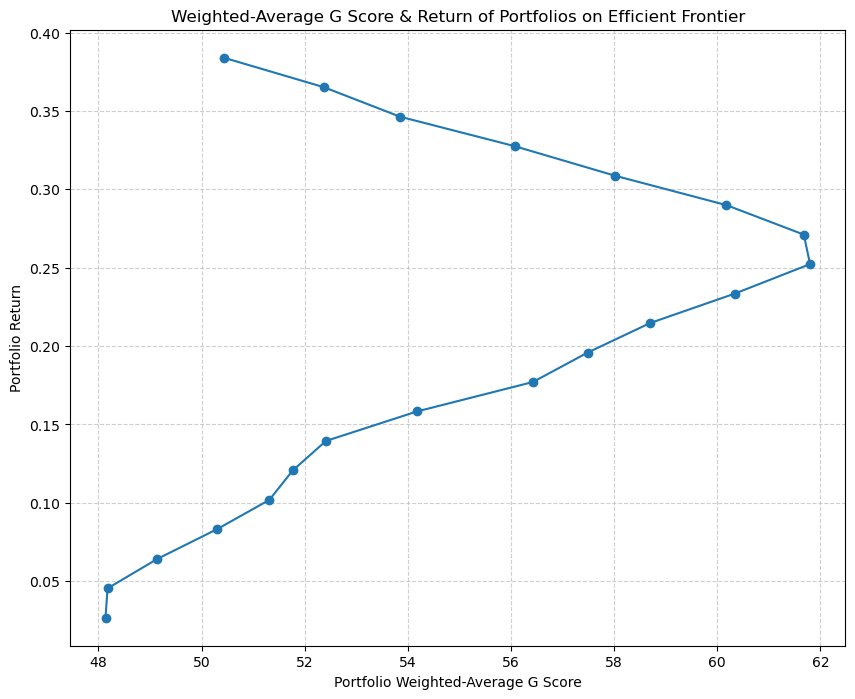

In [74]:
# plot in the GScore - return space the various portfolios
plt.figure(figsize=(10, 8))
plt.plot(GScore_ef, mus, 'o-')
plt.title('Weighted-Average G Score & Return of Portfolios on Efficient Frontier')
plt.xlabel("Portfolio Weighted-Average G Score")
plt.ylabel("Portfolio Return")
# plt.xticks(np.arange(0, 0.6, step=0.05))
# plt.yticks(np.arange(0, 0.5, step=0.05))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


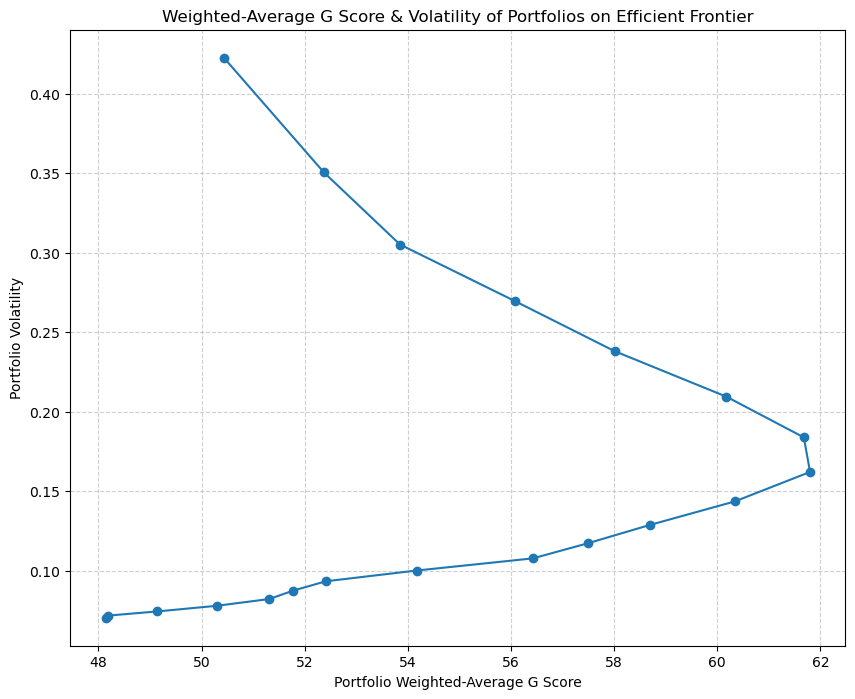

In [75]:
# plot in the GScore - volatility space the various portfolios
plt.figure(figsize=(10, 8))
plt.plot(GScore_ef, vols, 'o-')
plt.title('Weighted-Average G Score & Volatility of Portfolios on Efficient Frontier')
plt.xlabel("Portfolio Weighted-Average G Score")
plt.ylabel("Portfolio Volatility")
# plt.xticks(np.arange(0, 0.6, step=0.05))
# plt.yticks(np.arange(0, 0.5, step=0.05))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Q3

## Temporal Evolution of G Score

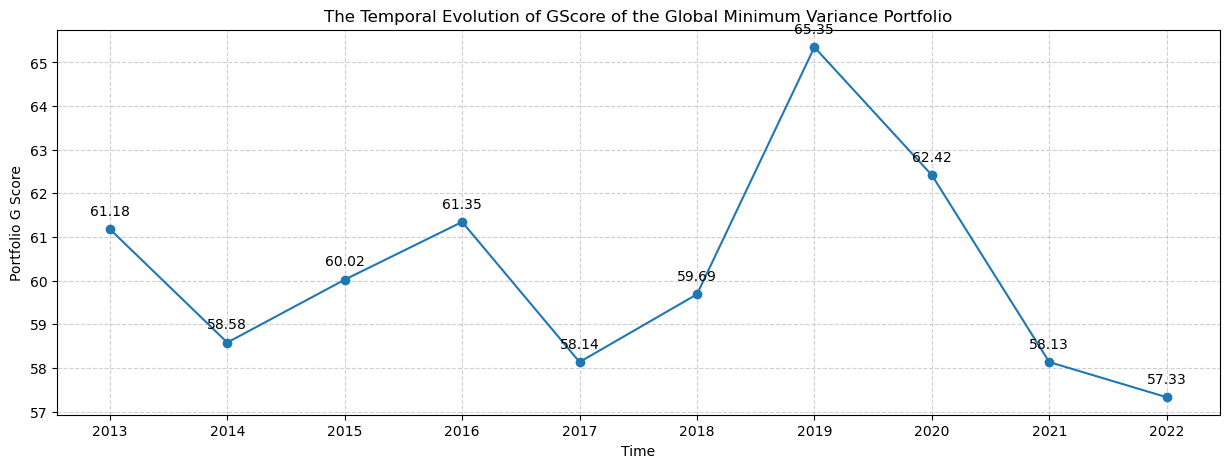

In [76]:
# the temporal evolution of GScore of the minimum variance portfolio
GScore_gmv = []
weights_gmv_y = []
for i in range(0, 10): 
    w = weights_gmv[i * 12]
    weights_gmv_y.append(w) # extract the yearly weights from monthly weights
    GScore_gmv.append((w @ GScore_1322.iloc[:, i])[0])
    # Weights are calculated at the end of Y-1 for year Y. Gscore is extracted from end of year Y-1.

# plot the temporal evolution
GScore_gmv_addtime = pd.DataFrame([GScore_gmv], columns=GScore_1322.columns)

plt.figure(figsize=(15, 5))
plt.plot(GScore_gmv, 'o-')
plt.title('The Temporal Evolution of GScore of the Global Minimum Variance Portfolio')
plt.xticks(ticks=range(10), labels=range(2013, 2023))
plt.xlabel("Time")
plt.ylabel("Portfolio G Score")
plt.grid(True, linestyle="--", alpha=0.6)
for i, value in enumerate(GScore_gmv):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

In [77]:
# reallocate the portfolio composition to improve GScore by 20%
start_index2 =[i for i in range(0, 109, 12)]
weights_gmv_improved = []
R_m_gmv_improved = []

for start in start_index2:
    df = temp0424.iloc[:, start:(start+tau)]
    cov_df = df.T.cov(ddof=0) * 12 # annualized covariance matrix
    cov_df_fixed = LedoitWolf().fit(df.T).covariance_ * (tau - 1) / tau  #fixed monthly covariance matrix

    alpha_df = cp.Variable((n,1))
    objective_rw_improved = cp.Minimize(cp.quad_form(alpha_df, cov_df_fixed))
    constraints_rw_improved = [cp.sum(alpha_df) == 1, 
                               alpha_df >= 0, 
                               (alpha_df.T @ GScore_1322.iloc[:, start // 12 ])[0] >= GScore_gmv[start // 12] * 1.2]
    
    prob_rw_improved = cp.Problem(objective_rw_improved, constraints_rw_improved)
    prob_rw_improved.solve(solver=cp.GUROBI)    

    alpha_df = alpha_df.value.reshape((1, -1))
    weights_gmv_improved.append(alpha_df)

    # compute the portfolio return for the Jan of each year
    r_p_jan = (alpha_df @ temp1424.iloc[:, start].values.reshape((-1, 1)))[0][0]
    R_m_gmv_improved.append(r_p_jan)

    alpha_df_temp = alpha_df.copy()
    r_p_temp = r_p_jan
    # update the monthly weight
    for i in range(1, 12):
        r = temp1424.iloc[:, start+i-1].values.reshape((-1, 1))
        update_coef = ((r + 1) / (1 + r_p_temp)).T  # shape: (1, n)
        alpha_df_temp = alpha_df_temp * update_coef
        weights_gmv_improved.append(alpha_df_temp)

        r_p_temp = (alpha_df_temp @ temp1424.iloc[:, start+i].values.reshape((-1, 1)))[0][0]
        R_m_gmv_improved.append(r_p_temp)


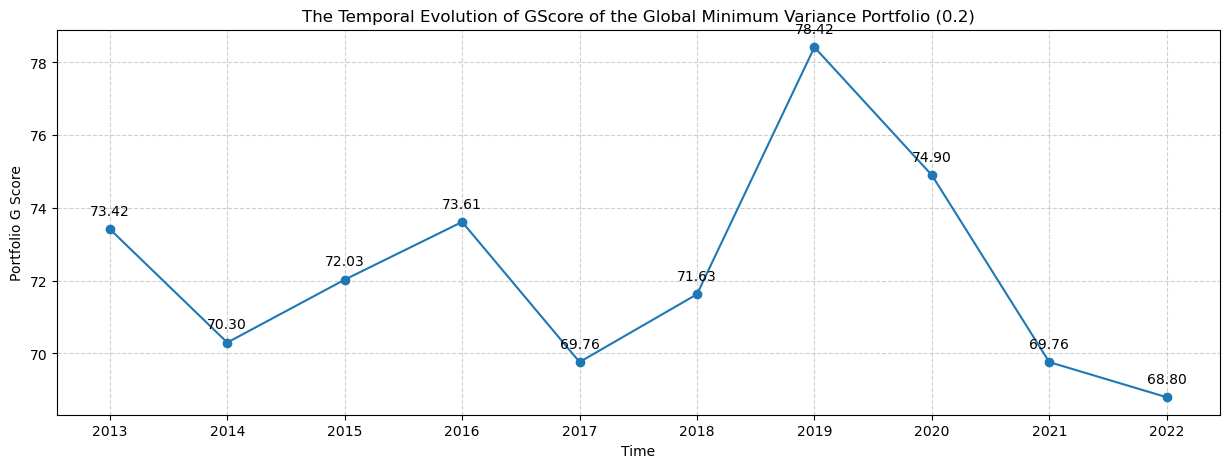

In [78]:
# the temporal evolution of improved GScore of the minimum variance portfolio
GScore_gmv_improved = []
weights_gmv_y_improved = []
for i in range(0, 10): 
    w = weights_gmv_improved[i * 12]
    weights_gmv_y_improved.append(w) # extract the yearly weights from monthly weights
    GScore_gmv_improved.append((w @ GScore_1322.iloc[:, i])[0])

# plot the temporal evolution
GScore_gmv_improved_addtime = pd.DataFrame([GScore_gmv_improved], columns=GScore_1322.columns)

plt.figure(figsize=(15, 5))
plt.plot(GScore_gmv_improved, 'o-')
plt.title('The Temporal Evolution of GScore of the Global Minimum Variance Portfolio (0.2)')
plt.xticks(ticks=range(10), labels=range(2013, 2023))
plt.xlabel("Time")
plt.ylabel("Portfolio G Score")
plt.grid(True, linestyle="--", alpha=0.6)
for i, value in enumerate(GScore_gmv_improved):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

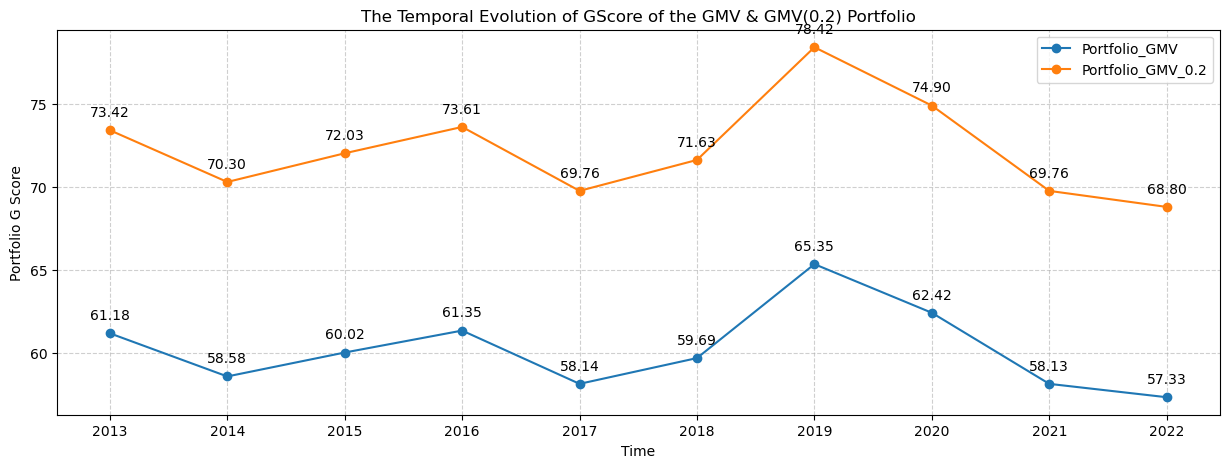

In [79]:
# comparison
plt.figure(figsize=(15, 5))
plt.plot(GScore_gmv, 'o-', label="Portfolio_GMV")
plt.plot(GScore_gmv_improved, 'o-', label="Portfolio_GMV_0.2")
plt.title('The Temporal Evolution of GScore of the GMV & GMV(0.2) Portfolio')
plt.xticks(ticks=range(10), labels=range(2013, 2023))
plt.xlabel("Time")
plt.ylabel("Portfolio G Score")
plt.grid(True, linestyle="--", alpha=0.6)
for i, value in enumerate(GScore_gmv):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
for i, value in enumerate(GScore_gmv_improved):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
plt.legend()
plt.show()

## Find the Excluded Firms in Portfolio_GMV(0.2)

In [80]:
# find firms need to be excluded in the most recent year (2023)
# the weights are calculated at the end of year 2022 for 2023
GScore_gmv_improved_23 = pd.concat([name_meta_633, pd.DataFrame(weights_gmv_y_improved[-1]).T], axis=1).rename(columns={0: 'Weights_improved_2023'})
GScore_gmv_23 = pd.concat([GScore_gmv_improved_23, pd.DataFrame(weights_gmv_y[-1]).T], axis=1).rename(columns={0: 'Weights_2023'})
GScore_gmv_23['Diff'] = GScore_gmv_23['Weights_2023'] - GScore_gmv_23['Weights_improved_2023']
GScore_gmv_23['Ratio'] = GScore_gmv_23['Diff'] / GScore_gmv_23['Weights_2023']
GScore_gmv_23_sorted = GScore_gmv_23.sort_values(by='Ratio', ascending=False)


# if the difference divided by the original weight is greater than 0.9, then exclude the firm
threshold = 1 - 1e-1
excluded_firms = GScore_gmv_23_sorted[GScore_gmv_23_sorted['Ratio'] >= threshold]
excluded_firms


,NAME,ISIN,Country,Weights_improved_2023,Weights_2023,Diff,Ratio
53,PSP SWISS PROPERTY AG,CH0018294154,CH,4.925020e-09,1.072465e-02,1.072465e-02,1.000000
24,COLRUYT GROUP,BE0974256852,BE,1.381955e-08,1.936807e-02,1.936805e-02,0.999999
244,ORANGE,FR0000133308,FR,7.680187e-09,7.118432e-03,7.118425e-03,0.999999
508,BEZEQ ISRAELI TELECOMMUNICATION,IL0002300114,IL,1.455840e-08,1.299009e-02,1.299008e-02,0.999999
512,FIRST INTL.BK.OF ISR.,IL0005930388,IL,2.215026e-08,1.598780e-02,1.598778e-02,0.999999
352,ULTRA ELECTRONICS DEAD - DELIST.02/08/22,GB0009123323,GB,1.244071e-08,8.401548e-03,8.401536e-03,0.999999
174,ZARDOYA OTIS DEAD - DELIST.09/05/22,ES0184933812,ES,4.561876e-09,1.427463e-03,1.427459e-03,0.999997
23,ELIA GROUP,BE0003822393,BE,7.493323e-09,1.765096e-03,1.765088e-03,0.999996
220,BIC,FR0000120966,FR,6.415985e-08,8.192366e-03,8.192302e-03,0.999992
515,MIZRAHI TEFAHOT LTD.,IL0006954379,IL,2.812623e-08,2.364527e-03,2.364499e-03,0.999988


## Calculate the Properties of P_GMV(0.2)

In [81]:
# compute the properties of the portfolio
R_m_gmv_improved = pd.DataFrame(R_m_gmv_improved)
R_m_gmv_improved.index = RF_m_temp.index[0: 120]
ann_avg_r_gmv_improved, ann_vol_gmv_improved, ann_sr_gmv_improved, R_m_gmv_improved_min, R_m_gmv_improved_max = portfolio_properties(R_m_gmv_improved)

Annualized average return: 0.00748131621007681
Annualized volatility: 0.1032968695779904
Sharpe ratio: -0.040351498057423184
Minimum return: -0.11570089931991438
Maximum return: 0.11315379817436834


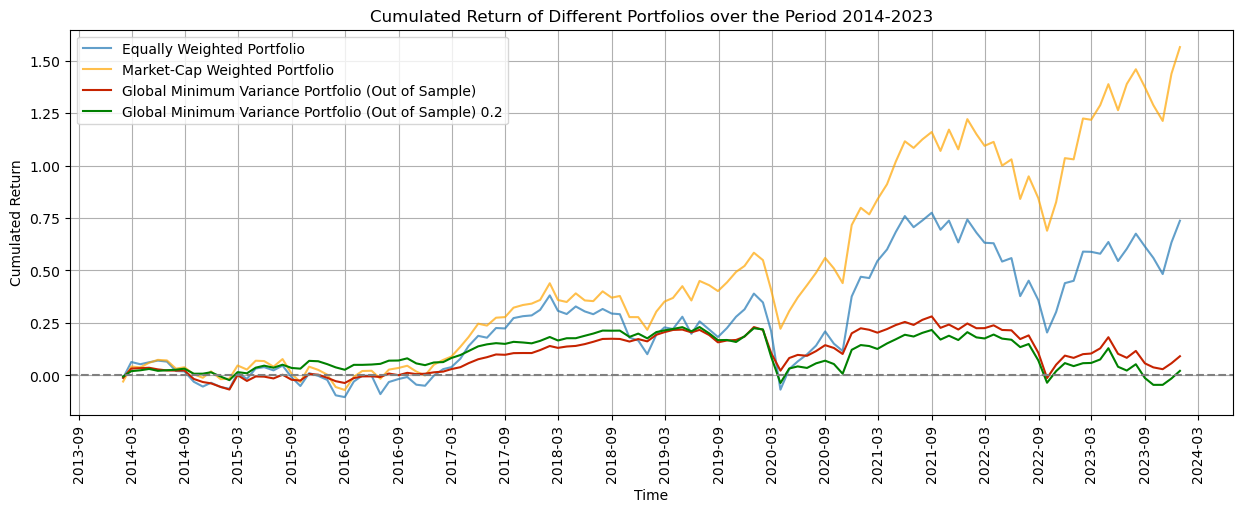

In [82]:
cum_r_m_gmv_improved = np.cumprod(1 + R_m_gmv_improved) - 1

# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1[0: 120], label="Equally Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_p2[0: 120], color="orange", label="Market-Cap Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_gmv[0: 120], color="#C62300", label="Global Minimum Variance Portfolio (Out of Sample)")
plt.plot(cum_r_m_gmv_improved, color="green", label="Global Minimum Variance Portfolio (Out of Sample) 0.2")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2023")
plt.legend()
plt.grid(True)
plt.show()

# Q4

In [83]:
# calculate the value weight for 2014-2023 at the end of last year

mc_weight_1323 = temp1323_mc.div(temp1323_mc.sum(axis=0), axis=1)

weights_vw_y = mc_weight_1323.iloc[:, [(i * 12 - 1) for i in range(1,11)]] # from end of year 2013 to end of year 2022

weights_vw_y_1423 = mc_weight_p2.iloc[:, [(i * 12 - 1) for i in range(1,11)]] # from end of year 2013 to end of year 2022


In [84]:
# calculate the G Score of VW portfolio over 2013-2022
GScore_vw = (weights_vw_y.values * GScore_1322.values).sum(axis=0)
GScore_vw


array([66.32246571, 65.66306559, 65.19949464, 65.60430597, 65.80816069,
       70.69478612, 70.94990262, 72.41906888, 71.84016656, 70.79639225])

In [85]:
# reallocate the portfolio composition to improve GScore by 20%
weights_vw_improved = []
R_m_vw_improved = []

for start in start_index2:
    df = temp0424.iloc[:, start:(start+tau)]
    cov_df = df.T.cov(ddof=0) * 12 # annualized covariance matrix
    cov_df_fixed = LedoitWolf().fit(df.T).covariance_ * (tau - 1) / tau  #fixed monthly covariance matrix

    alpha_df = cp.Variable((n,1))
    objective_vw_improved = cp.Minimize(cp.quad_form((alpha_df - weights_vw_y.iloc[:, start // 12].values.reshape((-1, 1))), cov_df_fixed))
    constraints_vw_improved = [cp.sum(alpha_df) == 1, 
                               alpha_df >= 0, 
                               (alpha_df.T @ GScore_1322.iloc[:, start // 12 ])[0] >= GScore_vw[start // 12] * 1.2]
    
    
    prob_vw_improved = cp.Problem(objective_vw_improved, constraints_vw_improved)
    prob_vw_improved.solve(solver=cp.GUROBI)    

    alpha_df = alpha_df.value.reshape((1, -1))
    weights_vw_improved.append(alpha_df)

    # compute the portfolio return for the Jan of each year
    r_p_jan = (alpha_df @ temp1424.iloc[:, start].values.reshape((-1, 1)))[0][0]
    R_m_vw_improved.append(r_p_jan)

    alpha_df_temp = alpha_df.copy()
    r_p_temp = r_p_jan
    # update the monthly weight
    for i in range(1, 12):
        r = temp1424.iloc[:, start+i-1].values.reshape((-1, 1))
        update_coef = ((r + 1) / (1 + r_p_temp)).T  # shape: (1, n)
        alpha_df_temp = alpha_df_temp * update_coef
        weights_vw_improved.append(alpha_df_temp)

        r_p_temp = (alpha_df_temp @ temp1424.iloc[:, start+i].values.reshape((-1, 1)))[0][0]
        R_m_vw_improved.append(r_p_temp)

In [86]:
# the temporal evolution of improved GScore of the minimum variance portfolio
GScore_vw_improved = []
weights_vw_y_improved = []
for i in range(0, 10): 
    w = weights_vw_improved[i * 12]
    weights_vw_y_improved.append(w) # extract the yearly weights from monthly weights
    GScore_vw_improved.append((w @ GScore_1322.iloc[:, i])[0])

# GScore_vw_improved_addtime = pd.DataFrame([GScore_vw_improved], columns=GScore_1423.columns)

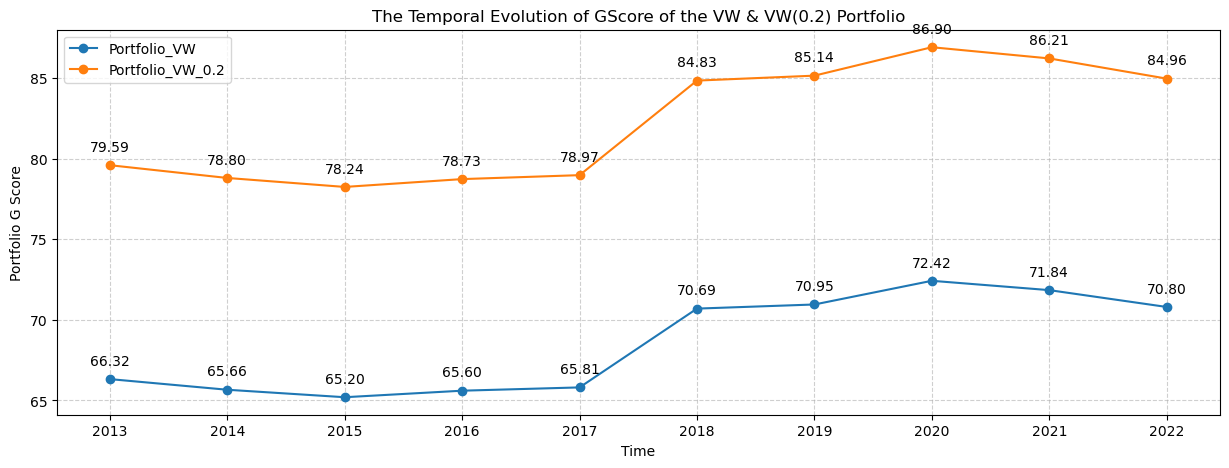

In [87]:
# compare vw & vw(0.2)
plt.figure(figsize=(15, 5))
plt.plot(GScore_vw, 'o-', label="Portfolio_VW")
plt.plot(GScore_vw_improved, 'o-', label="Portfolio_VW_0.2")
plt.title('The Temporal Evolution of GScore of the VW & VW(0.2) Portfolio')
plt.xticks(ticks=range(10), labels=range(2013, 2023))
plt.xlabel("Time")
plt.ylabel("Portfolio G Score")
plt.grid(True, linestyle="--", alpha=0.6)
for i, value in enumerate(GScore_vw):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
for i, value in enumerate(GScore_vw_improved):
    plt.annotate(f'{value:.2f}', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
plt.legend()
plt.show()

In [88]:
# compute the properties of the portfolio
R_m_vw_improved = pd.DataFrame(R_m_vw_improved)
R_m_vw_improved.index = RF_m_temp.index[0: 120]
ann_avg_r_vw_improved, ann_vol_vw_improved, ann_sr_vw_improved, R_m_vw_improved_min, R_m_vw_improved_max = portfolio_properties(R_m_vw_improved)

Annualized average return: 0.0593102146304262
Annualized volatility: 0.16769662628542667
Sharpe ratio: 0.28435363014888493
Minimum return: -0.15794242990717797
Maximum return: 0.18474421185012083


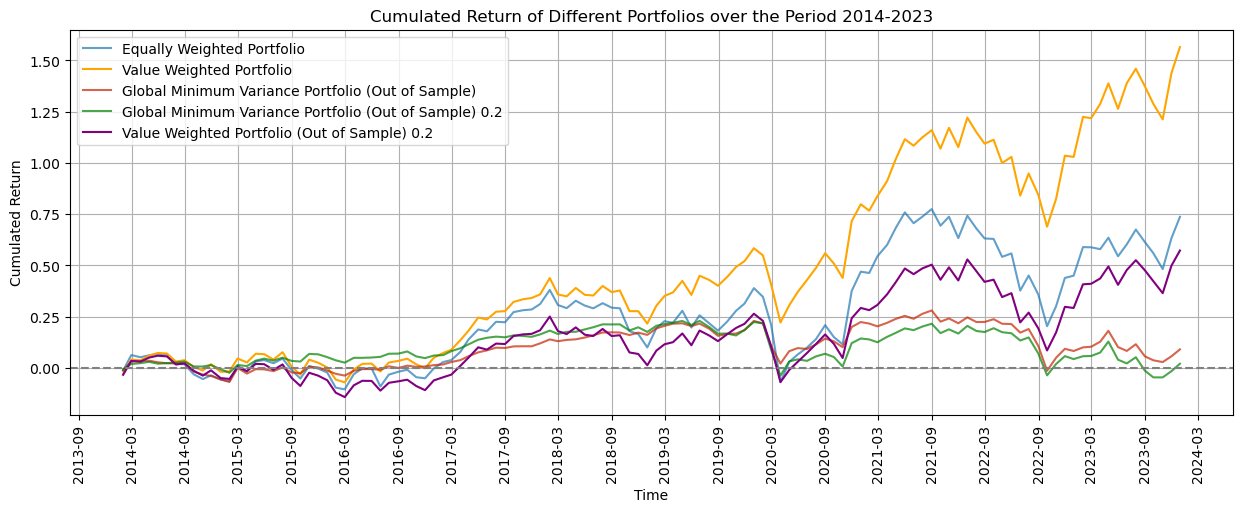

In [89]:
cum_r_m_vw_improved = np.cumprod(1 + R_m_vw_improved) - 1

# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1[0: 120], label="Equally Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_p2[0: 120], color="orange", label="Value Weighted Portfolio")
plt.plot(cum_r_m_gmv[0: 120], color="#C62300", label="Global Minimum Variance Portfolio (Out of Sample)", alpha=0.7)
plt.plot(cum_r_m_gmv_improved, color="green", label="Global Minimum Variance Portfolio (Out of Sample) 0.2", alpha=0.7)
plt.plot(cum_r_m_vw_improved, color="purple", label="Value Weighted Portfolio (Out of Sample) 0.2")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2023")
plt.legend()
plt.grid(True)
plt.show()

# Extensions

## Why the cumulated return of VW(0.2) is worse than EW portfolio?

In [90]:
# copy the market-cap at end of year Y-1 for every month in year Y
mc_test1=[]
for i in range (0, 10):
    alpha = weights_vw_y.iloc[:, i]
    mc_test1.append(alpha)
    for j in range(1, 12):
        mc_test1.append(alpha)


mc_test1 = pd.DataFrame(mc_test1).T
mc_test1.columns = temp1424.iloc[:, 0:-12].columns

In [91]:
weights_vw_test1 = mc_test1.div(mc_test1.sum(axis=0), axis=1)
R_m_vw_test1 = (temp1424.iloc[:, 0:-12] * weights_vw_test1).sum(axis=0)

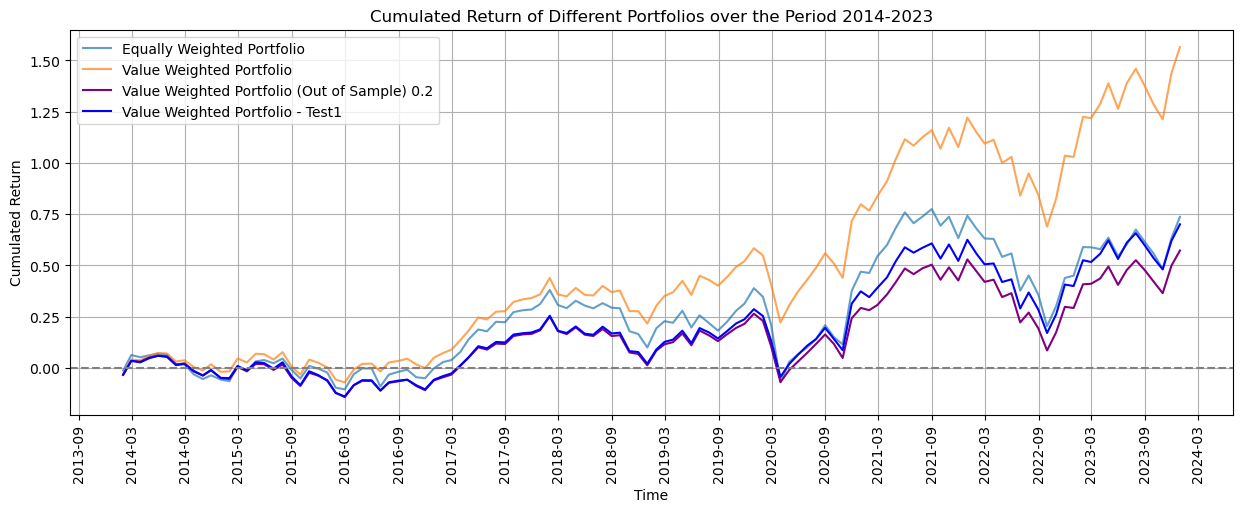

In [92]:
cum_r_m_vw_test1 = np.cumprod(1 + R_m_vw_test1) - 1

# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1[0: 120], label="Equally Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_p2[0: 120], label="Value Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_vw_improved, color="purple", label="Value Weighted Portfolio (Out of Sample) 0.2")
plt.plot(cum_r_m_vw_test1, color="blue", label="Value Weighted Portfolio - Test1") 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2023")
plt.legend()
plt.grid(True)
plt.show()

Note: 

EW portfolio may perform well?
1. higher exposure to small-cap stocks, which tend to offer higher long-term returns
2. regular rebalancing increases exposure to underperformers and enforces a "buy low, sell high" discipline
3. diversification benefit makes portfolio less prone to idiosyncratic risk from individual mega-cap companies

## Construct a portfolio close to benchmark, but with higher return?

In [93]:
mu1424 # out-of-sample annualized expected return

,2014-01-31 00:00:00,2015-01-30 00:00:00,2016-01-29 00:00:00,2017-01-31 00:00:00,2018-01-31 00:00:00,2019-01-31 00:00:00,2020-01-31 00:00:00,2021-01-29 00:00:00,2022-01-31 00:00:00,2023-01-31 00:00:00,2024-01-31 00:00:00
0,0.029084,-0.002708,0.003287,0.040590,0.082483,0.142364,0.077421,0.080432,0.114985,0.121546,0.125376
1,0.132139,0.112208,0.100534,0.105778,0.137948,0.217463,0.178008,0.134832,0.178804,0.137212,0.149328
2,0.119693,0.007868,-0.015079,-0.033731,0.051904,0.147602,0.026265,-0.000728,0.079793,0.018702,0.045516
3,0.157120,0.065488,0.082419,0.059037,0.146619,0.210824,0.079879,0.047930,0.160981,0.105577,0.114464
4,0.039749,-0.010776,-0.053113,-0.055795,-0.012477,0.018392,0.013059,0.002730,0.026084,0.042341,0.069369
...,...,...,...,...,...,...,...,...,...,...,...
628,0.322461,0.322070,0.178602,0.199345,0.298170,0.376174,0.149588,0.138475,0.168842,0.180768,0.154938
629,0.158374,0.161844,0.156193,0.148811,0.197041,0.251235,0.155858,0.119641,0.145220,0.142899,0.128295
630,0.135184,0.048976,0.117276,0.107276,0.058463,0.061961,0.027628,0.036907,0.170407,0.149263,0.053897
631,0.066625,0.100701,0.072320,0.033144,-0.009523,0.012437,-0.063529,-0.039229,-0.057320,-0.013579,-0.012115


In [94]:
# optimization
weights_vw_test2 = []
R_m_vw_test2 = []
track_error_test2_before = []
track_error_test2_after = []

for start in start_index2:
    df = temp0424.iloc[:, start:(start+tau)]
    cov_df = df.T.cov(ddof=0) * 12 # annualized covariance matrix
    cov_df_fixed = LedoitWolf().fit(df.T).covariance_ * (tau - 1) / tau  #fixed monthly covariance matrix

    # optimization 1
    alpha_df_1 = cp.Variable((n, 1))
    objective_vw_test2_1 = cp.Minimize(cp.quad_form((alpha_df_1 - weights_vw_y.iloc[:, start // 12].values.reshape((-1, 1))), cov_df_fixed))
    constraints_vw_test2_1 = [cp.sum(alpha_df_1) == 1, 
                               alpha_df_1 >= 0, 
                               (alpha_df_1.T @ GScore_1322.iloc[:, start // 12 ])[0] >= GScore_vw[start // 12] * 1.2]
    prob_vw_test2_1 = cp.Problem(objective_vw_test2_1, constraints_vw_test2_1)
    result1 = prob_vw_test2_1.solve(solver=cp.GUROBI) 
    track_error_test2_before.append(result1)

    # optimization 2
    alpha_df = cp.Variable((n, 1))
    objective_vw_test2_2 = cp.Maximize(cp.matmul(alpha_df.T, mu1424.iloc[:, start // 12]))
    constraints_vw_test2_2 = [cp.sum(alpha_df) == 1,
                              alpha_df >= 0,
                              (alpha_df.T @ GScore_1322.iloc[:, start // 12])[0] >= GScore_vw[start // 12] * 1.2,
                              cp.quad_form((alpha_df - weights_vw_y.iloc[:, start // 12].values.reshape((-1, 1))), cov_df_fixed) <= 10 * result1]
    
    prob_vw_test2_2 = cp.Problem(objective_vw_test2_2, constraints_vw_test2_2)
    prob_vw_test2_2.solve(solver=cp.GUROBI)

    result2 = cp.quad_form((alpha_df - weights_vw_y.iloc[:, start // 12].values.reshape((-1, 1))), cov_df_fixed)
    track_error_test2_after.append(result2.value[0][0])

    alpha_df = alpha_df.value.reshape((1, -1))
    weights_vw_test2.append(alpha_df)

    # compute the portfolio return for the Jan of each year
    r_p_jan = (alpha_df @ temp1424.iloc[:, start].values.reshape((-1, 1)))[0][0]
    R_m_vw_test2.append(r_p_jan)

    alpha_df_temp = alpha_df.copy()
    r_p_temp = r_p_jan
    # update the monthly weight
    for i in range(1, 12):
        r = temp1424.iloc[:, start+i-1].values.reshape((-1, 1))
        update_coef = ((r + 1) / (1 + r_p_temp)).T  # shape: (1, n)
        alpha_df_temp = alpha_df_temp * update_coef
        weights_vw_test2.append(alpha_df_temp)

        r_p_temp = (alpha_df_temp @ temp1424.iloc[:, start+i].values.reshape((-1, 1)))[0][0]
        R_m_vw_test2.append(r_p_temp)

In [95]:
track_error_test2_before

[3.1830967824717017e-06,
 2.985028494570629e-06,
 2.8293150433475243e-06,
 2.92786077852616e-06,
 3.051227149894979e-06,
 4.574438425861592e-06,
 3.7098259838734192e-06,
 8.284326608415869e-06,
 8.146696330683879e-06,
 7.186661807586277e-06]

In [96]:
track_error_test2_after

[3.18303402410629e-05,
 2.984989437768258e-05,
 2.829314142470175e-05,
 2.9278453350470225e-05,
 3.0512270865033506e-05,
 4.574436714792498e-05,
 3.709821313175629e-05,
 8.284323936024857e-05,
 8.146691651894992e-05,
 7.186655076850932e-05]

In [97]:
R_m_vw_test2 = pd.DataFrame(R_m_vw_test2)
R_m_vw_test2.index = R_m_vw_test1.index
ann_avg_r_vw_test2, ann_vol_vw_test2, ann_sr_vw_test2, R_m_vw_test2_min, R_m_vw_test2_max = portfolio_properties(R_m_vw_test2)

Annualized average return: 0.07676536048473404
Annualized volatility: 0.1716364193136247
Sharpe ratio: 0.37968716079228026
Minimum return: -0.17516189328243797
Maximum return: 0.16211944736093872


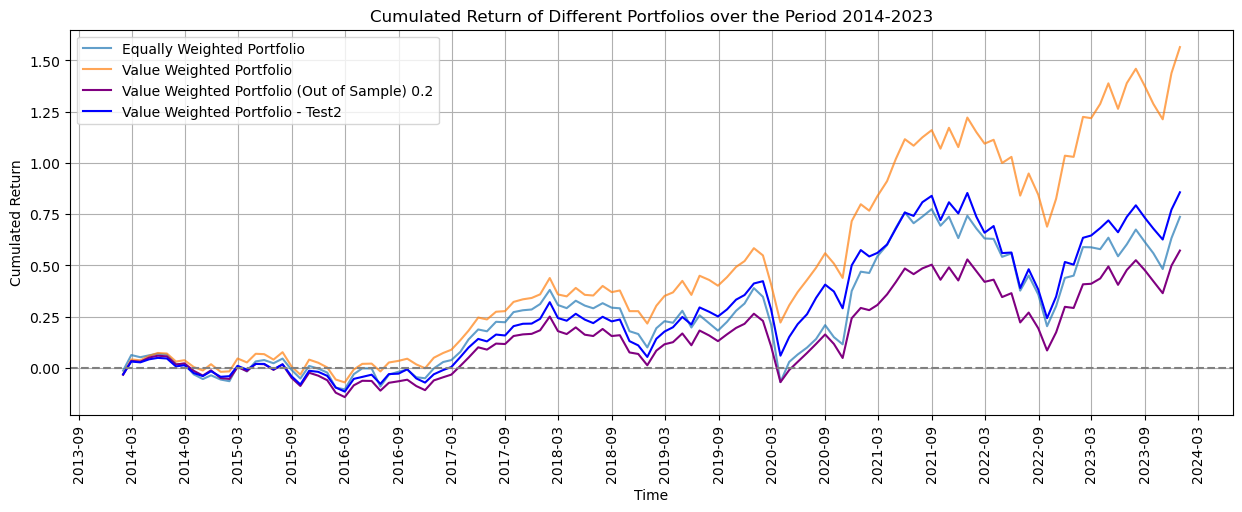

In [98]:
cum_r_m_vw_test2 = np.cumprod(1 + R_m_vw_test2) - 1

# plot cumulated return together for comparison
plt.figure(figsize=(15, 5))
plt.plot(cum_r_m_p1[0: 120], label="Equally Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_p2[0: 120], label="Value Weighted Portfolio", alpha=0.7)
plt.plot(cum_r_m_vw_improved, color="purple", label="Value Weighted Portfolio (Out of Sample) 0.2")
plt.plot(cum_r_m_vw_test2, color="blue", label="Value Weighted Portfolio - Test2") 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.xticks(rotation=90)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Cumulated Return")
plt.title("Cumulated Return of Different Portfolios over the Period 2014-2023")
plt.legend()
plt.grid(True)
plt.show()

# Maps


In [99]:
# read geographic data
europe_gdf = gpd.read_file("./CNTR_RG_20M_2024_3035/CNTR_RG_20M_2024_3035.shp")

iso3_matching = pd.read_csv("iso3_matching.csv")

In [100]:
df_map = pd.concat([GScore_avg_withname, pd.DataFrame(ann_avg_r,  columns=["Annualized_Average_Return"])], axis=1)
df_map

,NAME,ISIN,Country,Average_GScore,Annualized_Average_Return
0,STRABAG SE,AT000000STR1,AT,65.718000,0.127820
1,FLUGHAFEN WIEN,AT00000VIE62,AT,24.011000,0.136039
2,RAIFFEISEN BANK INTL.,AT0000606306,AT,32.625000,0.059285
3,ERSTE GROUP BANK,AT0000652011,AT,65.929000,0.148044
4,TELEKOM AUSTRIA,AT0000720008,AT,37.663000,0.077698
...,...,...,...,...,...
628,BOLIDEN ORD SHS,SE0020050417,SE,61.446000,0.150719
629,AUTOLIV,US0528001094,SE,71.357400,0.108420
630,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,US70211M1099,IL,36.481786,0.046749
631,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,US8816242098,IL,82.193571,0.061144


In [101]:
country_count = pd.DataFrame(columns=["Country", "Country_Count"])
for index, row in df_map.iterrows():
    if row["Country"] in country_count["Country"].values:
        country_count.loc[country_count["Country"] == row["Country"], "Country_Count"] += 1
    
    else:
        new_row = pd.DataFrame({"Country": row["Country"], "Country_Count": 1}, index=[0])
        country_count = pd.concat([country_count, new_row],ignore_index=True)


In [102]:
country_count = country_count.assign(Country_Average_GScore=np.nan, Country_Average_Return=np.nan)
for index, row in country_count.iterrows():
    country_count.loc[index, "Country_Average_GScore"] = df_map.loc[df_map["Country"] == row["Country"], "Average_GScore"].mean()
    country_count.loc[index, "Country_Average_Return"] = df_map.loc[df_map["Country"] == row["Country"], "Annualized_Average_Return"].mean()

country_count

,Country,Country_Count,Country_Average_GScore,Country_Average_Return
0,AT,13,54.849385,0.080038
1,IE,19,58.566353,0.100265
2,BE,17,53.108289,0.052804
3,GB,233,61.242684,0.069103
4,CH,46,62.951724,0.088834
5,DE,53,63.381271,0.054873
6,DK,17,51.392450,0.109380
7,ES,29,52.301517,0.042269
8,FI,19,61.478232,0.082721
9,FR,67,59.631460,0.058235


## Maps on Raw Data

In [103]:
country_count_gdf = europe_gdf.merge(country_count.merge(iso3_matching, on="Country"), on="ISO3_CODE")
country_count_gdf

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry,Country,Country_Count,Country_Average_GScore,Country_Average_Return
0,AT,Österreich,Austria,Autriche,AUT,UN Member State,Vienna,T,F,F,Österreich,"POLYGON ((4742889.363 2876362.718, 4783414.299...",AT,13,54.849385,0.080038
1,BE,Belgien-Belgique-België,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((3957506.807 3167694.490, 3965222.940...",BE,17,53.108289,0.052804
2,DE,Deutschland,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((4264045.794 3530123.451, 42756...",DE,53,63.381271,0.054873
3,DK,Danmark,Denmark,Danemark,DNK,UN Member State,Copenhagen,T,F,F,Dänemark,"MULTIPOLYGON (((4647850.201 3557634.614, 46440...",DK,17,51.392450,0.109380
4,CH,Schweiz-Suisse-Svizzera-Svizra,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"POLYGON ((4221123.490 2731035.913, 4230514.918...",CH,46,62.951724,0.088834
5,FI,Suomi-Finland,Finland,Finlande,FIN,UN Member State,Helsinki,T,F,F,Finnland,"MULTIPOLYGON (((5000971.593 5305047.277, 50298...",FI,19,61.478232,0.082721
6,FR,France,France,France,FRA,UN Member State,Paris,T,F,F,Frankreich,"MULTIPOLYGON (((10022966.561 -3053183.012, 100...",FR,67,59.631460,0.058235
7,ES,España,Spain,Espagne,ESP,UN Member State,Madrid,T,F,F,Spanien,"MULTIPOLYGON (((3831423.288 1892159.335, 38003...",ES,29,52.301517,0.042269
8,IE,Ireland-Éire,Ireland,Irlande,IRL,UN Member State,Dublin,T,F,F,Irland,"MULTIPOLYGON (((3248492.228 3698352.067, 32303...",IE,19,58.566353,0.100265
9,IL,إسرائيل-ישראל,Israel,Israël,ISR,UN Member State,Jerusalem (Disputed),F,F,F,Israel,"POLYGON ((6696603.517 1530051.996, 6701400.082...",IL,15,46.630283,0.105848


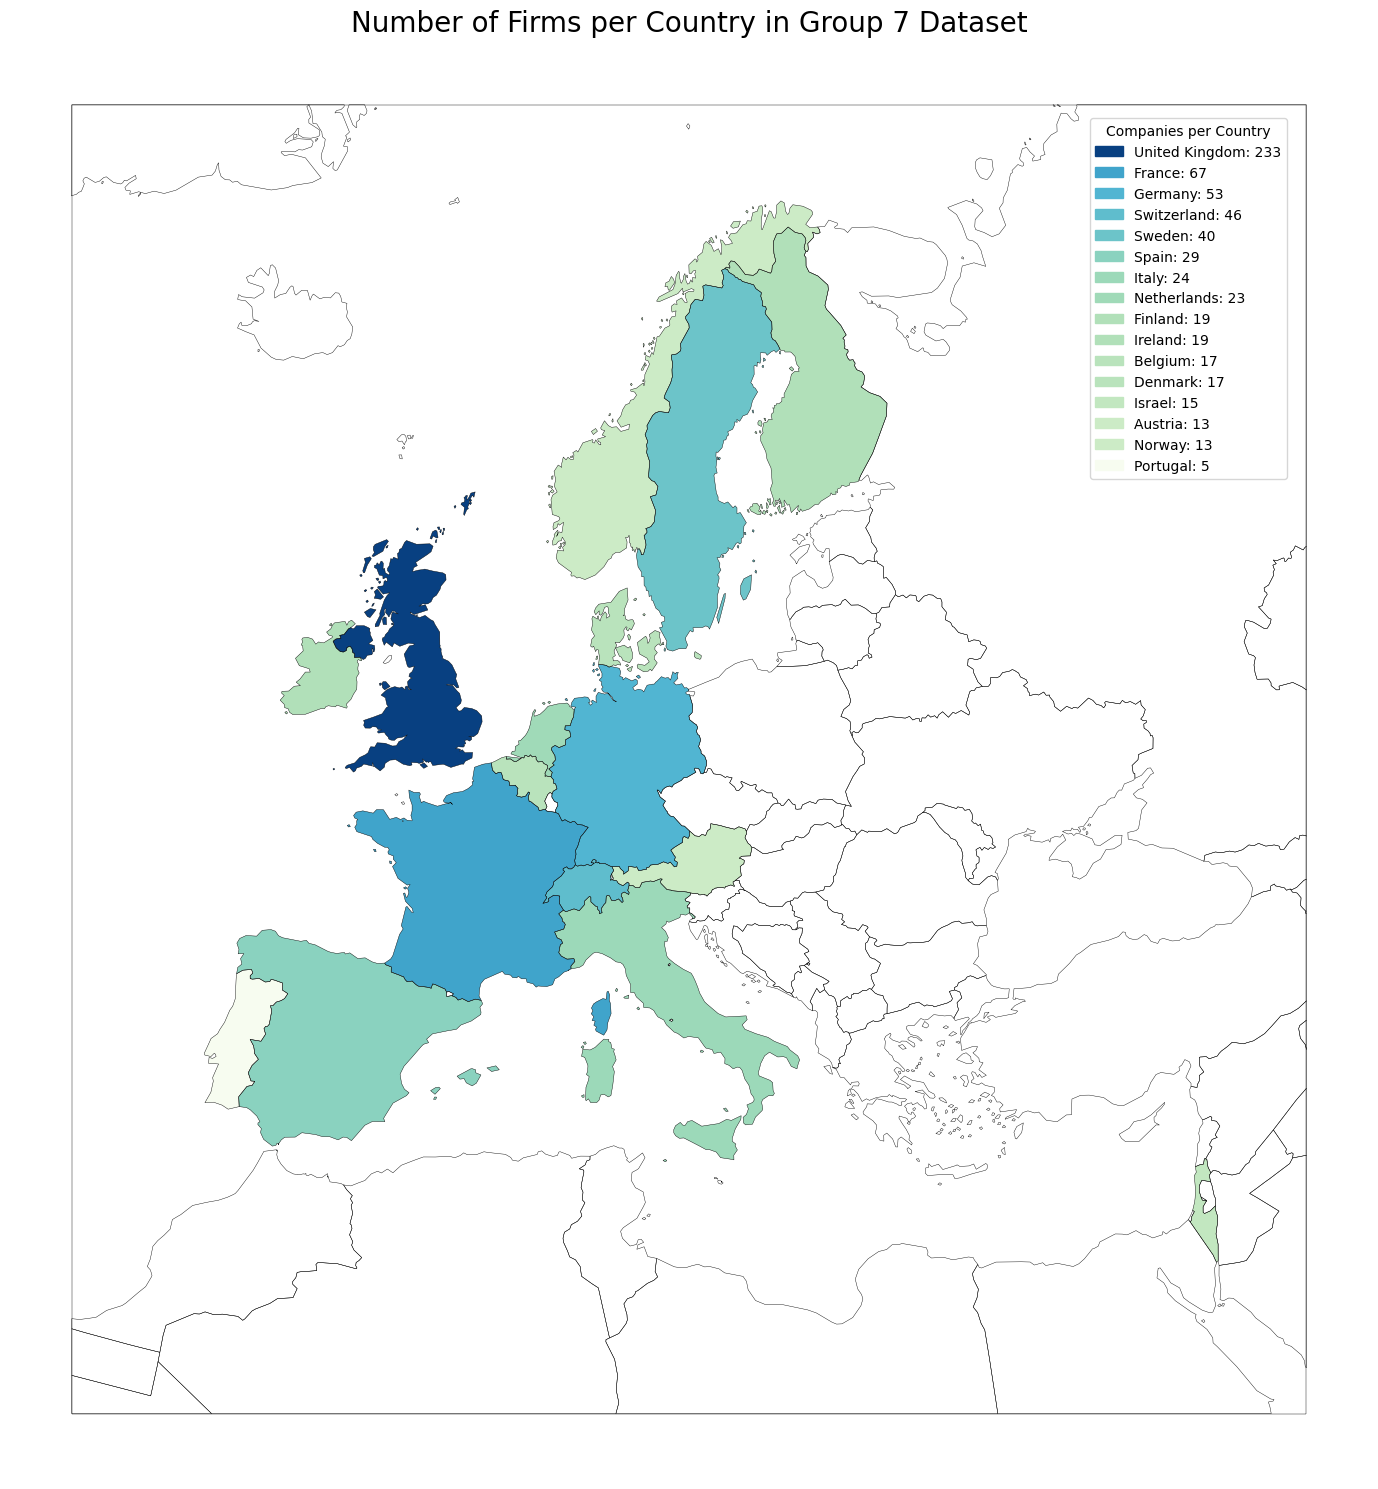

In [104]:
# Define the bounding box for Europe
minx = 2.1e6
miny = 5e5
maxx = 7.1e6
maxy = 5.8e6

europe_bounding_box = box(minx, miny, maxx, maxy)
europe_geo = gpd.GeoSeries([europe_bounding_box]).set_crs("EPSG:3035")
europe_gdf_clipped = europe_gdf.copy()
europe_gdf_clipped['geometry'] = europe_gdf_clipped.geometry.intersection(europe_geo.unary_union)
country_count_gdf_clipped = country_count_gdf.copy()
country_count_gdf_clipped['geometry'] = country_count_gdf_clipped.geometry.intersection(europe_geo.unary_union)

# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.GnBu
norm = mcolors.LogNorm(vmin=country_count_gdf_clipped["Country_Count"].min(), 
                      vmax=country_count_gdf_clipped["Country_Count"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors'] = country_count_gdf_clipped['Country_Count'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors'], ax=ax)

# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Count', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Count'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {int(row['Country_Count'])}")

ax.legend(handles=handles, 
         labels=labels,
         title='Companies per Country',
         loc='center left',
         bbox_to_anchor=(0.79, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Number of Firms per Country in Group 7 Dataset", fontsize=20)

plt.tight_layout()
plt.show()

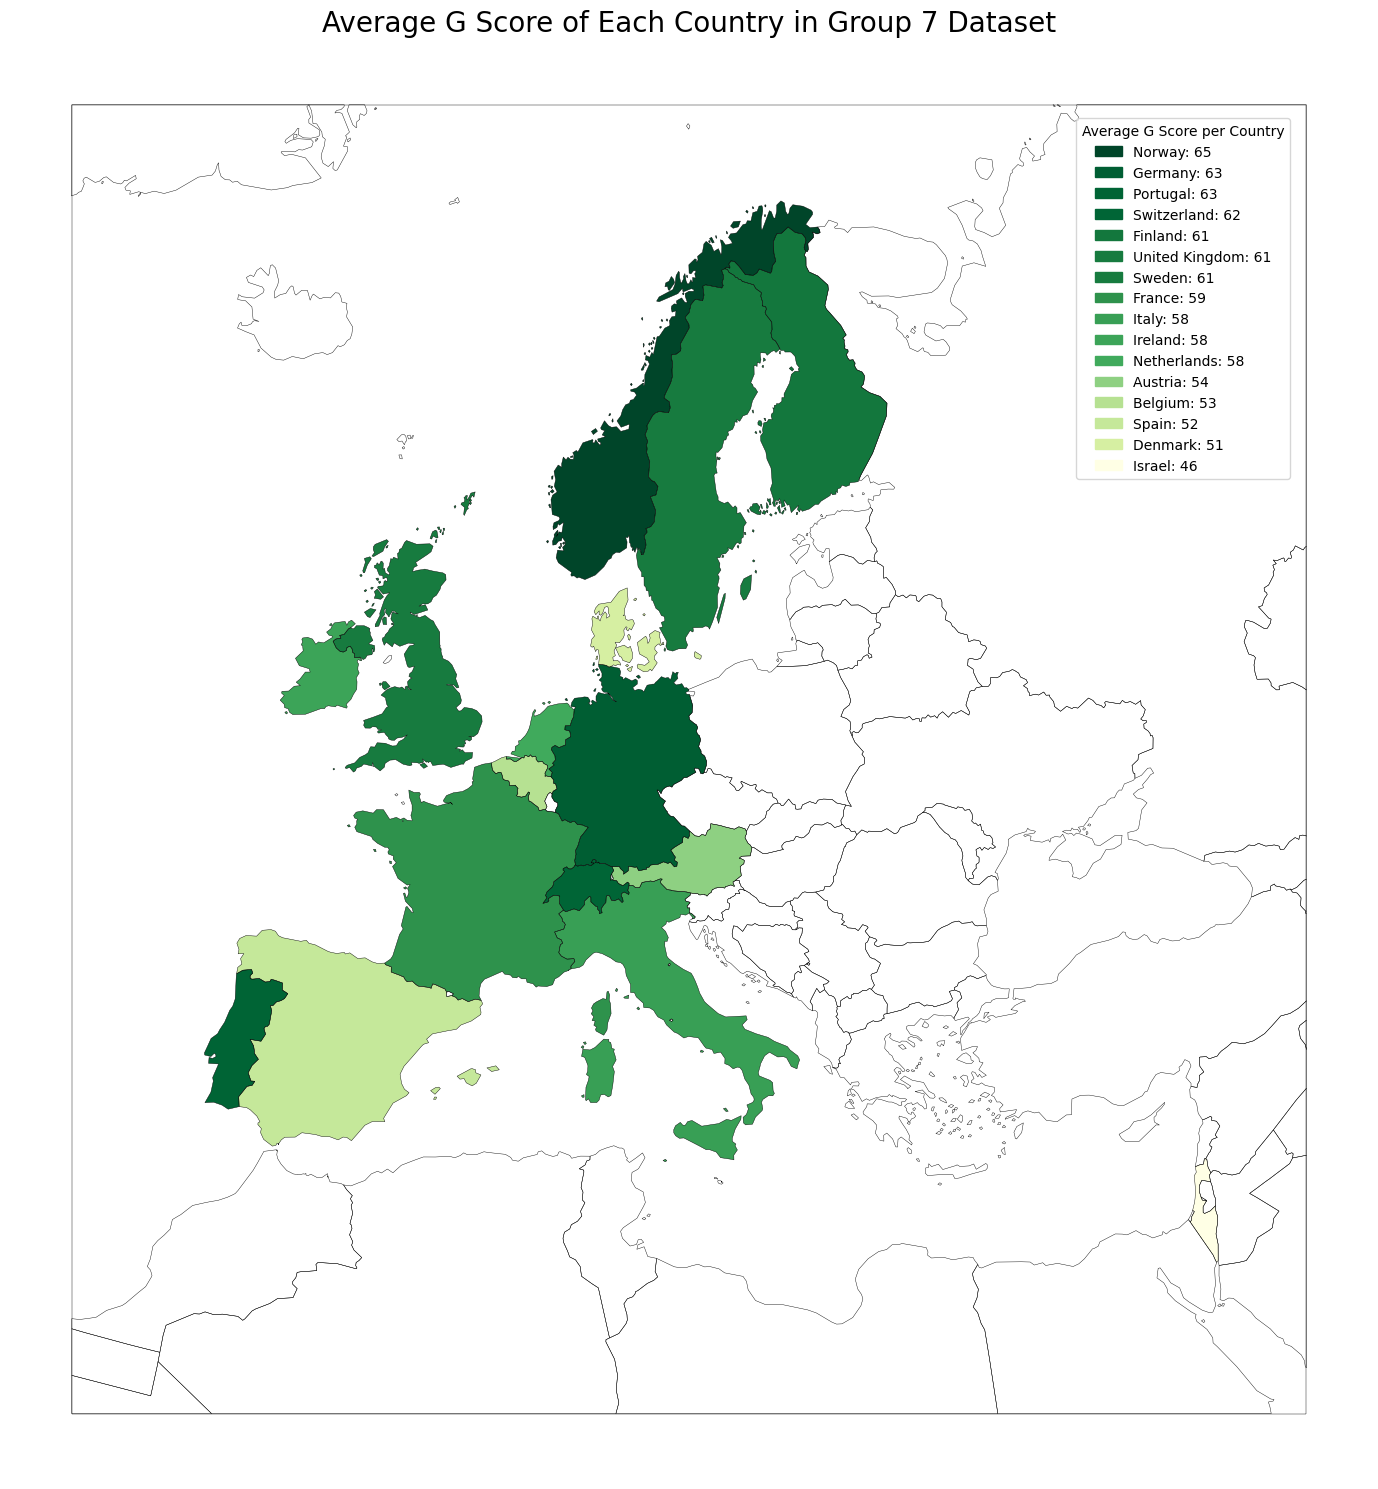

In [105]:
# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=country_count_gdf_clipped["Country_Average_GScore"].min(), 
                      vmax=country_count_gdf_clipped["Country_Average_GScore"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors_gscore'] = country_count_gdf_clipped['Country_Average_GScore'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors_gscore'], ax=ax)

# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Average_GScore', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Average_GScore'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {int(row['Country_Average_GScore'])}")

ax.legend(handles=handles, 
         labels=labels,
         title='Average G Score per Country',
         loc='center left',
         bbox_to_anchor=(0.78, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Average G Score of Each Country in Group 7 Dataset", fontsize=20)

plt.tight_layout()
plt.show()

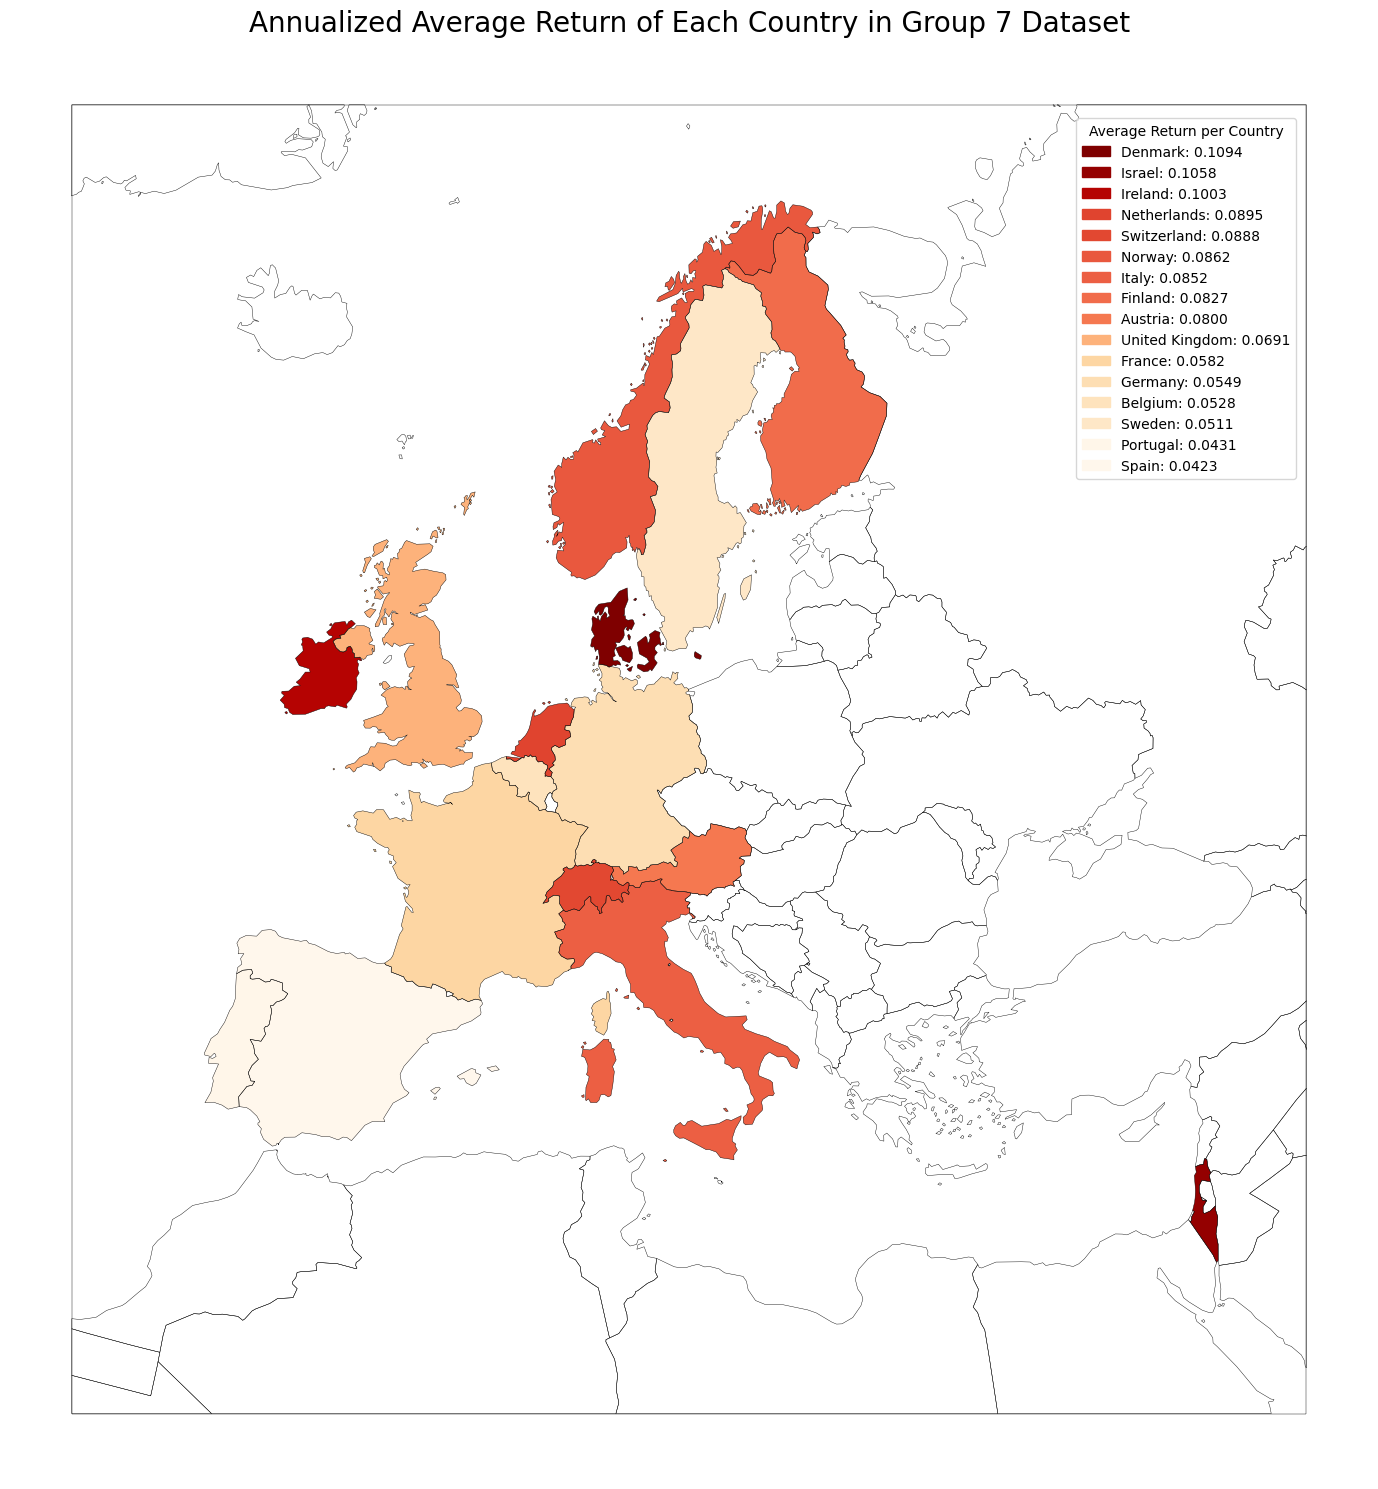

In [106]:
# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.OrRd
norm = mcolors.Normalize(vmin=country_count_gdf_clipped["Country_Average_Return"].min(), 
                      vmax=country_count_gdf_clipped["Country_Average_Return"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors_return'] = country_count_gdf_clipped['Country_Average_Return'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors_return'], ax=ax)

# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Average_Return', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Average_Return'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {row['Country_Average_Return']:.4f}")

ax.legend(handles=handles, 
         labels=labels,
         title='Average Return per Country',
         loc='center left',
         bbox_to_anchor=(0.78, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Annualized Average Return of Each Country in Group 7 Dataset", fontsize=20)

plt.tight_layout()
plt.show()

## Maps on Bad Firms

### Approach 1: 10 firms with lowest average G Score

In [107]:
GScore_avg_worst10 = GScore_avg_withname_sorted.head(10)
GScore_avg_worst10

,NAME,ISIN,Country,Average_GScore
518,DELEK GROUP,IL0010841281,IL,4.595000
511,ISRAEL CORPORATION LTD.,IL0005760173,IL,6.128000
162,OBRASCON HUARTE LAIN,ES0142090317,ES,13.073333
161,FAES FARMA,ES0134950F36,ES,13.435778
17,SOFINA,BE0003717312,BE,16.867000
293,TOWN CENTRE SECURITIES,GB0003062816,GB,17.130000
262,ANGLO-EASTERN PLTNS.,GB0000365774,GB,17.357500
195,SECHE ENVIRONNEMENT,FR0000039109,FR,18.365000
70,FLUGHAFEN ZURICH,CH0319416936,CH,18.974364
512,FIRST INTL.BK.OF ISR.,IL0005930388,IL,19.195000


In [108]:
GScore_avg_worst10_gdf = europe_gdf.merge(GScore_avg_worst10.merge(iso3_matching, on="Country"), on="ISO3_CODE")

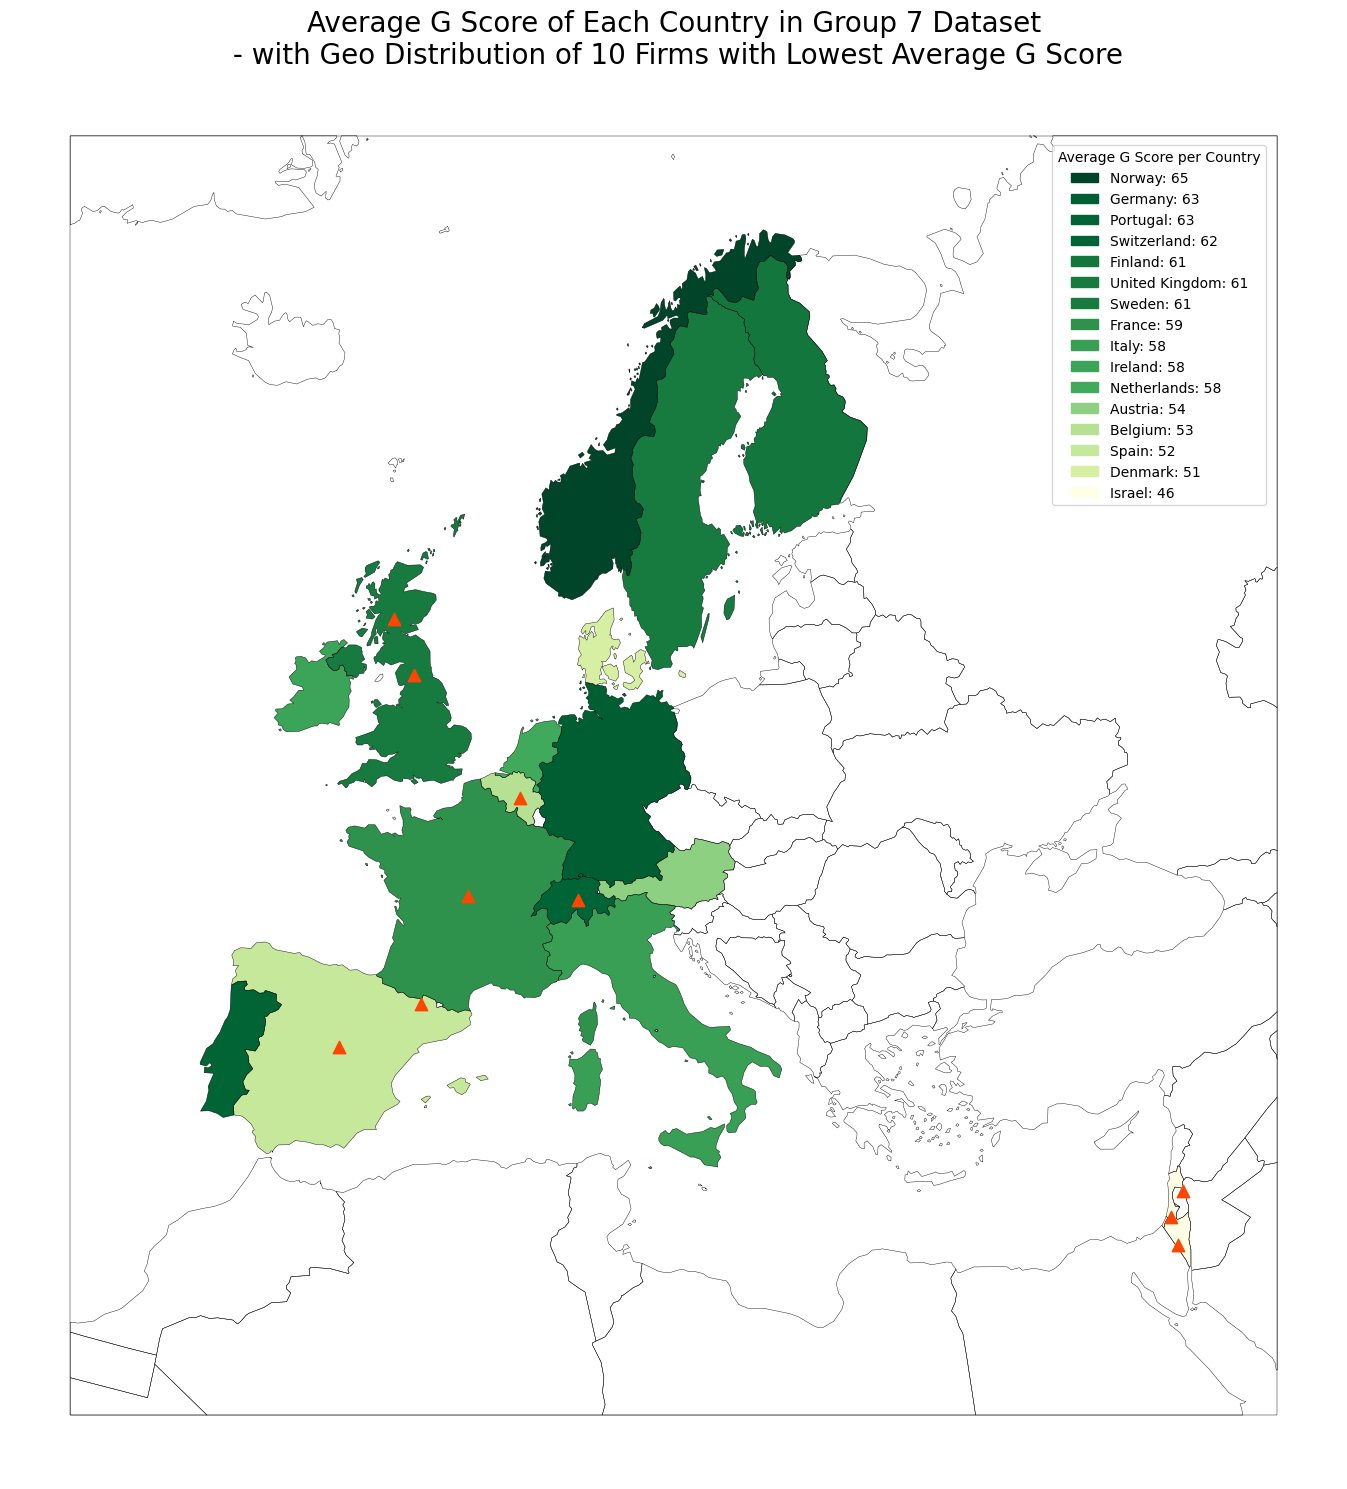

In [109]:
# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=country_count_gdf_clipped["Country_Average_GScore"].min(), 
                      vmax=country_count_gdf_clipped["Country_Average_GScore"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors_gscore'] = country_count_gdf_clipped['Country_Average_GScore'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors_gscore'], ax=ax)

country_count = {}
point_list = []
# Add markers for each row in worst 10 dataframe
for idx, row in GScore_avg_worst10_gdf.iterrows():
    country_iso = row['ISO3_CODE']
    
    # Initialize counter for this country if not exists
    if country_iso not in country_count:
        country_count[country_iso] = 0
    
    # Get the country geometry
    country_geom = country_count_gdf_clipped[country_count_gdf_clipped['ISO3_CODE'] == country_iso].geometry.iloc[0]
    
    # Get centroid
    center = country_geom.representative_point()
    bounds = country_geom.bounds
    width = bounds[2] - bounds[0]
    height = bounds[3] - bounds[1]

    if (country_count[country_iso] == 0):
        point_x = center.x
        point_y = center.y
    else:
        # Generate random location within the boundary
        point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
        point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)
        # Check if the point is within the geometry
        while not country_geom.contains(Point(point_x, point_y)):
            point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
            point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)
        # Check if the point is within range of the existing points
        while any(np.linalg.norm(np.array((point_x, point_y)) - np.array(existing_point)) < 1e5 for existing_point in point_list):
            point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
            point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)
    
    # Plot the marker
    ax.scatter(point_x, point_y, color='orangered', marker='^', s=80, zorder=5)

    point_list.append((point_x, point_y))
    
    # Increment the counter for this country
    country_count[country_iso] += 1


# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Average_GScore', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Average_GScore'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {int(row['Country_Average_GScore'])}")

ax.legend(handles=handles, 
         labels=labels,
         title='Average G Score per Country',
         loc='center left',
         bbox_to_anchor=(0.78, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Average G Score of Each Country in Group 7 Dataset\n - with Geo Distribution of 10 Firms with Lowest Average G Score", fontsize=20)

plt.tight_layout()
plt.show()

### Approach 2: Frequency

In [110]:
contribution_count
contribution_count_gdf = europe_gdf.merge(contribution_count.merge(iso3_matching, on="Country"), on="ISO3_CODE")

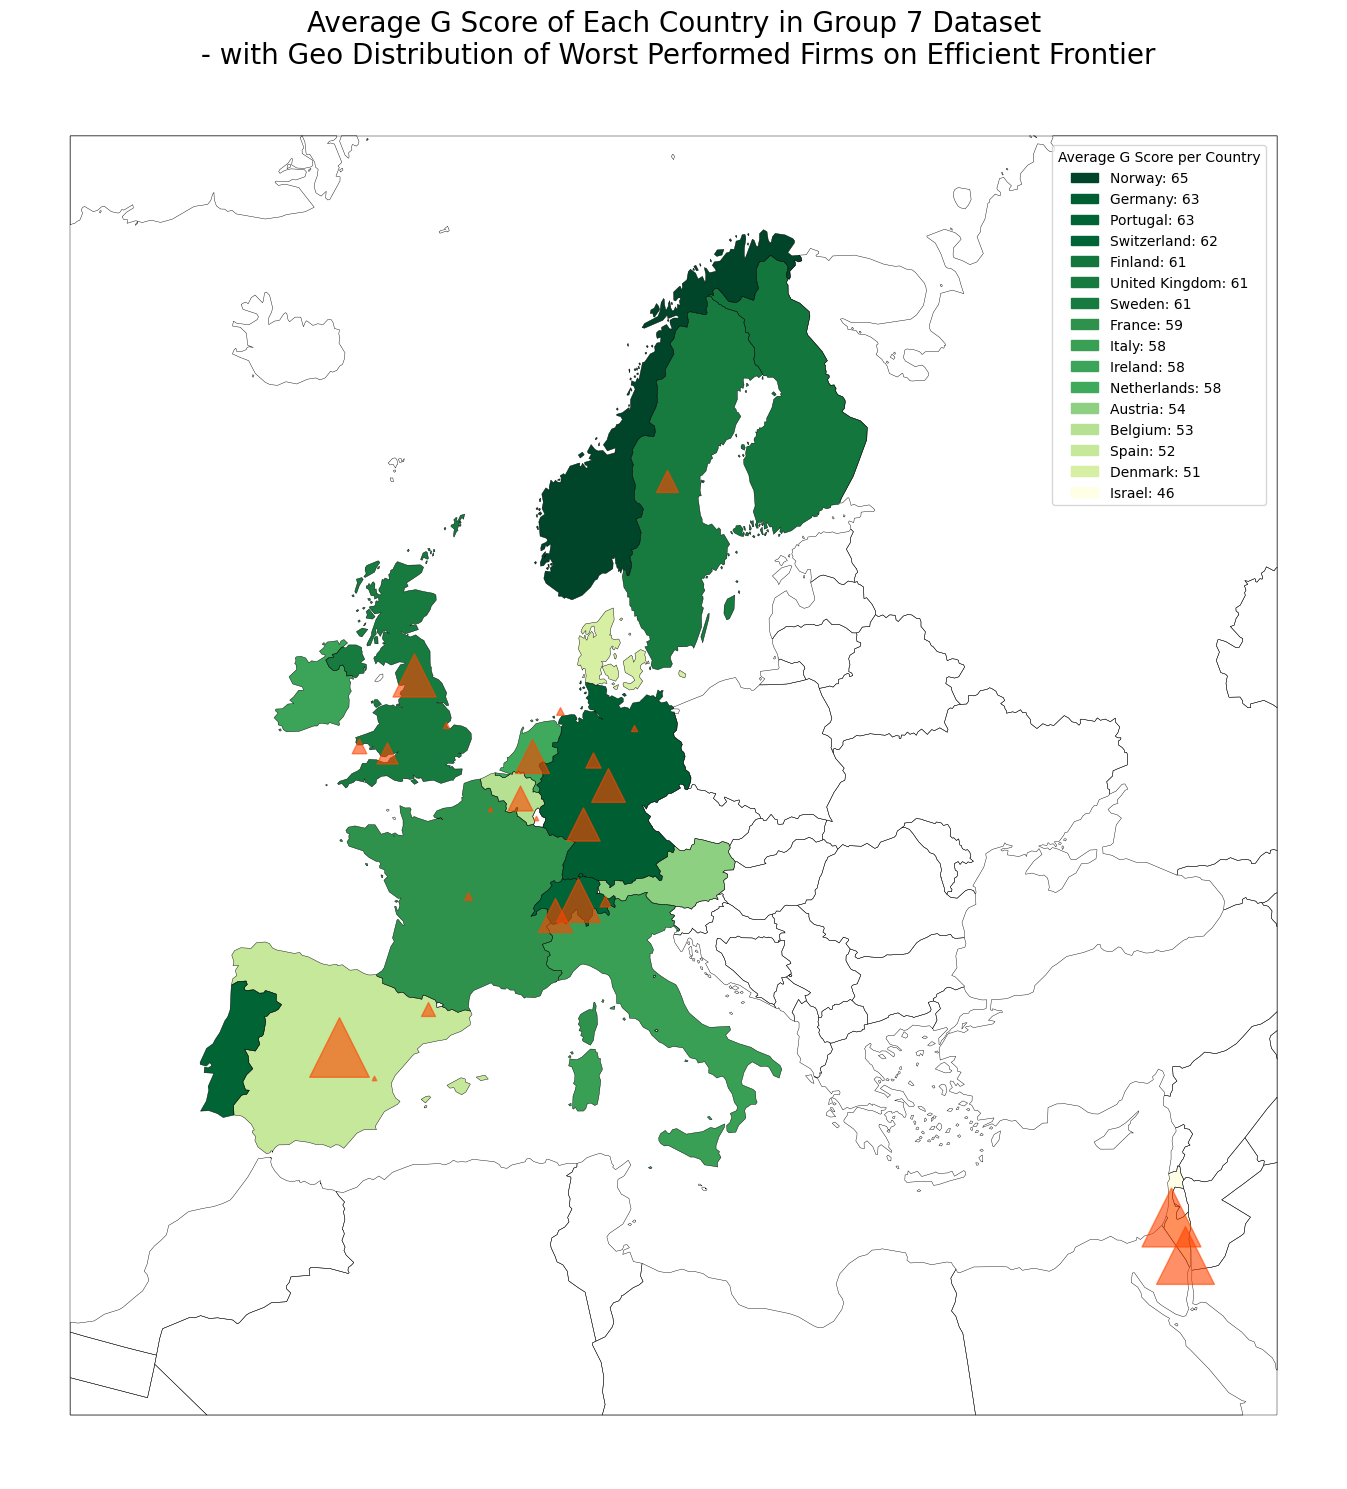

In [111]:
# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=country_count_gdf_clipped["Country_Average_GScore"].min(), 
                      vmax=country_count_gdf_clipped["Country_Average_GScore"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors_gscore'] = country_count_gdf_clipped['Country_Average_GScore'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors_gscore'], ax=ax)

country_count = {}
point_list = []
# Add markers for each row in worst 10 dataframe
for idx, row in contribution_count_gdf.iterrows():
    country_iso = row['ISO3_CODE']
    
    # Initialize counter for this country if not exists
    if country_iso not in country_count:
        country_count[country_iso] = 0
    
    # Get the country geometry
    country_geom = country_count_gdf_clipped[country_count_gdf_clipped['ISO3_CODE'] == country_iso].geometry.iloc[0]
    
    # Get centroid
    center = country_geom.representative_point()
    bounds = country_geom.bounds
    width = bounds[2] - bounds[0]
    height = bounds[3] - bounds[1]

    if (country_count[country_iso] == 0):
        point_x = center.x
        point_y = center.y
    else:
        # Generate random location within the boundary
        point_x = np.random.uniform(bounds[0] + width / 10, bounds[2] - width / 10)
        point_y = np.random.uniform(bounds[1] + height / 10, bounds[3] - height/ 10)
        # Check if the point is within the geometry
        while not country_geom.contains(Point(point_x, point_y)):
            point_x = np.random.uniform(bounds[0] + width / 10, bounds[2] - width / 10)
            point_y = np.random.uniform(bounds[1] + height / 10, bounds[3] - height/ 10)
        # Check if the point is within range of the existing points
        while any(np.linalg.norm(np.array((point_x, point_y)) - np.array(existing_point)) < 1e5 for existing_point in point_list):
            point_x = np.random.uniform(bounds[0] + width / 10, bounds[2] - width / 10)
            point_y = np.random.uniform(bounds[1] + height / 10, bounds[3] - height/ 10)
    
    # Plot the marker
    ax.scatter(point_x, point_y, marker='^', s=row["Rank_sum"] * 10, zorder=5, alpha=0.6, color="orangered")

    point_list.append((point_x, point_y))
    
    # Increment the counter for this country
    country_count[country_iso] += 1


# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Average_GScore', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Average_GScore'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {int(row['Country_Average_GScore'])}")

ax.legend(handles=handles, 
         labels=labels,
         title='Average G Score per Country',
         loc='center left',
         bbox_to_anchor=(0.78, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Average G Score of Each Country in Group 7 Dataset\n - with Geo Distribution of Worst Performed Firms on Efficient Frontier", fontsize=20)

plt.tight_layout()
plt.show()

## Maps on Excluded Firms

In [112]:
excluded_firms
excluded_firms_gdf = europe_gdf.merge(excluded_firms.merge(iso3_matching, on="Country"), on="ISO3_CODE")

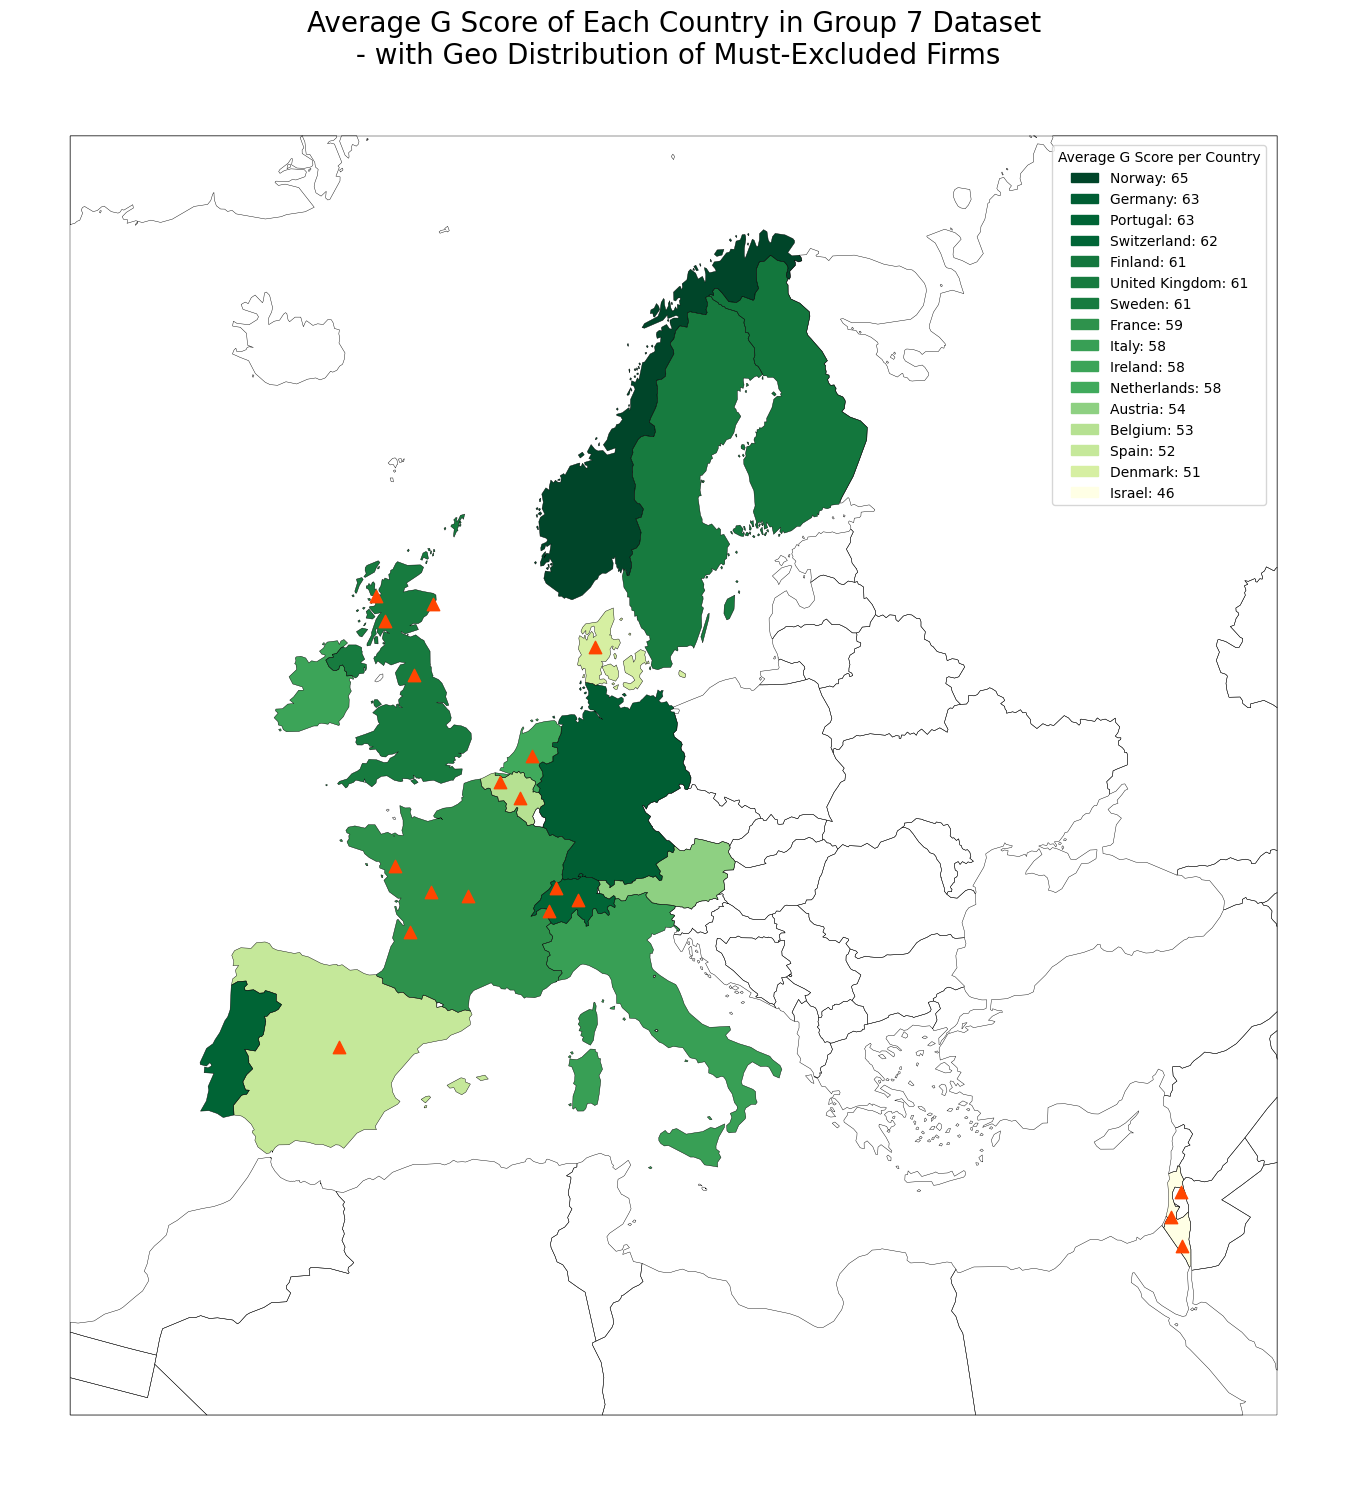

In [113]:
# Create a figure and an axes with the specified size
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the boundary
europe_gdf_clipped.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')
europe_geo.boundary.plot(ax=ax, linewidth=0.3, edgecolor='black')

# Define the color map
cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=country_count_gdf_clipped["Country_Average_GScore"].min(), 
                      vmax=country_count_gdf_clipped["Country_Average_GScore"].max())

# Calculate and store the color value
country_count_gdf_clipped['colors_gscore'] = country_count_gdf_clipped['Country_Average_GScore'].apply(lambda x: mcolors.rgb2hex(cmap(norm(x))))

# Plot the map with the calculated color
country_count_gdf_clipped.plot(color=country_count_gdf_clipped['colors_gscore'], ax=ax)

country_count = {}
point_list = []
# Add markers for each row in worst 10 dataframe
for idx, row in excluded_firms_gdf.iterrows():
    country_iso = row['ISO3_CODE']
    
    # Initialize counter for this country if not exists
    if country_iso not in country_count:
        country_count[country_iso] = 0
    
    # Get the country geometry
    country_geom = country_count_gdf_clipped[country_count_gdf_clipped['ISO3_CODE'] == country_iso].geometry.iloc[0]
    
    # Get centroid
    center = country_geom.representative_point()
    bounds = country_geom.bounds
    width = bounds[2] - bounds[0]
    height = bounds[3] - bounds[1]

    if (country_count[country_iso] == 0):
        point_x = center.x
        point_y = center.y
    else:
        # Generate random location within the boundary
        point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
        point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)
        # Check if the point is within the geometry
        while not country_geom.contains(Point(point_x, point_y)):
            point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
            point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)
        # Check if the point is within range of the existing points
        while any(np.linalg.norm(np.array((point_x, point_y)) - np.array(existing_point)) < 1e5 for existing_point in point_list):
            point_x = np.random.uniform(bounds[0] + width / 5, bounds[2] - width / 5)
            point_y = np.random.uniform(bounds[1] + height / 5, bounds[3] - height/ 5)

    # Plot the marker
    ax.scatter(point_x, point_y, color='orangered', marker='^', s=80, zorder=5)

    point_list.append((point_x, point_y))
    
    # Increment the counter for this country
    country_count[country_iso] += 1


# Create the legends
handles = []
labels = []
sorted_data = country_count_gdf_clipped.sort_values('Country_Average_GScore', ascending=False)

for idx, row in sorted_data.iterrows():
    color = mcolors.rgb2hex(cmap(norm(row['Country_Average_GScore'])))
    handle = mpatches.Patch(color=color)
    handles.append(handle)
    labels.append(f"{row['NAME_ENGL']}: {int(row['Country_Average_GScore'])}")

ax.legend(handles=handles, 
         labels=labels,
         title='Average G Score per Country',
         loc='center left',
         bbox_to_anchor=(0.78, 0.82),
         prop={'size': 10})

ax.axis('off')
ax.set_title("Average G Score of Each Country in Group 7 Dataset\n - with Geo Distribution of Must-Excluded Firms", fontsize=20)

plt.tight_layout()
plt.show()